In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from astropy.io import fits
from astropy.table import Table
import astropy.units as u
import astropy.coordinates as coord


from scipy.optimize import minimize
from scipy.optimize import least_squares


from sklearn.preprocessing import RobustScaler
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
Table = pd.read_parquet("GDR3_200pc.parquet")
print(Table.head())

   random_index           source_id         ra        dec  parallax  \
0    1156469439  138965694087518464  46.532926  36.396588  5.297268   
1     650499055  138929204045977344  46.276709  36.057550  6.670779   
2     827391995  139146533684727296  47.432017  36.498804  7.562804   
3      26579863  139015760521805312  46.500862  36.547116  5.018720   
4     255180152  138962777805261440  46.596825  36.403297  5.205753   

   parallax_error  parallax_over_error      pmdec  pmdec_error       pmra  \
0        0.158347            33.453583 -28.678846     0.156311  63.183360   
1        0.759255             8.785951 -39.751432     0.573725   4.221899   
2        0.121603            62.192330 -77.895497     0.134427  71.958596   
3        0.110103            45.582140   1.198930     0.091088  13.198361   
4        0.063591            81.863410   0.866839     0.058624  -9.644068   

   pmra_error  phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag     bp_rp  \
0    0.182518        17.943321

In [5]:
print(Table.info())
print(Table.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3217487 entries, 0 to 3217486
Data columns (total 17 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   random_index                 int64  
 1   source_id                    int64  
 2   ra                           float64
 3   dec                          float64
 4   parallax                     float64
 5   parallax_error               float64
 6   parallax_over_error          float64
 7   pmdec                        float64
 8   pmdec_error                  float64
 9   pmra                         float64
 10  pmra_error                   float64
 11  phot_g_mean_mag              float64
 12  phot_bp_mean_mag             float64
 13  phot_rp_mean_mag             float64
 14  bp_rp                        float64
 15  phot_g_mean_flux_over_error  float64
 16  phot_bp_rp_excess_factor     float64
dtypes: float64(15), int64(2)
memory usage: 417.3 MB
None
Index(['random_index', 'source_

In [6]:
#All data
pmra = Table['pmra']
pmdec = Table['pmdec']
parallax = Table['parallax']
parallax_over_error = Table['parallax_over_error']
    
ra = Table['ra']
dec = Table['dec']

g_mag = Table['phot_g_mean_mag']
bp_rp = Table['bp_rp']

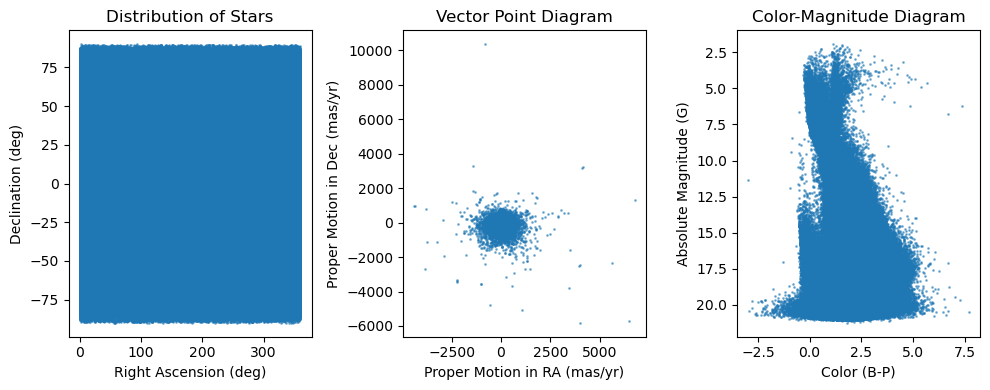

3217487


<Figure size 640x480 with 0 Axes>

In [11]:
plt.figure(figsize=(10, 4))
plt.subplot(1,3,1)
plt.scatter(ra, dec, s=1, alpha=0.5)
plt.xlabel('Right Ascension (deg)')
plt.ylabel('Declination (deg)')
plt.title('Distribution of Stars')
plt.subplot(1,3,2)
plt.scatter(pmra, pmdec, s=1, alpha=0.5)
plt.xlabel('Proper Motion in RA (mas/yr)')
plt.ylabel('Proper Motion in Dec (mas/yr)')
plt.title('Vector Point Diagram')
plt.subplot(1,3,3)
plt.scatter(bp_rp, g_mag, s=1, alpha=0.5)
plt.xlabel('Color (B-P)')
plt.ylabel('Absolute Magnitude (G)')
plt.title('Color-Magnitude Diagram')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.savefig('gaia_plots.png', dpi=300)
print(len(ra))

In [5]:
len(Table['random_index'].unique())

3217487

### Division del cielo

In [6]:
# Definir bins en 64 regiones iguales
ra_bins = np.linspace(np.min(ra), np.max(ra), 9)
dec_bins = np.linspace(np.min(dec), np.max(dec), 9)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43

Región 44 RA: [225.00, 270.00] | DEC: [-22.48, 0.01]
Clusters encontrados:
  Ruido: 79454
  Cluster 0: 124
  Cluster 1: 681
  Cluster 2: 203
  Cluster 3: 50866
  Cluster 4: 116


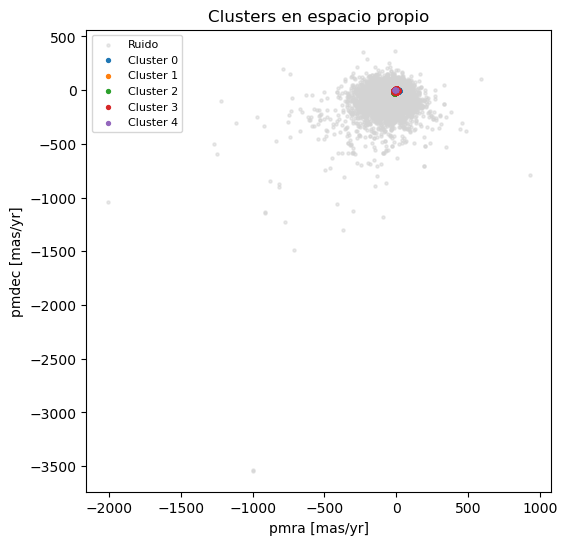

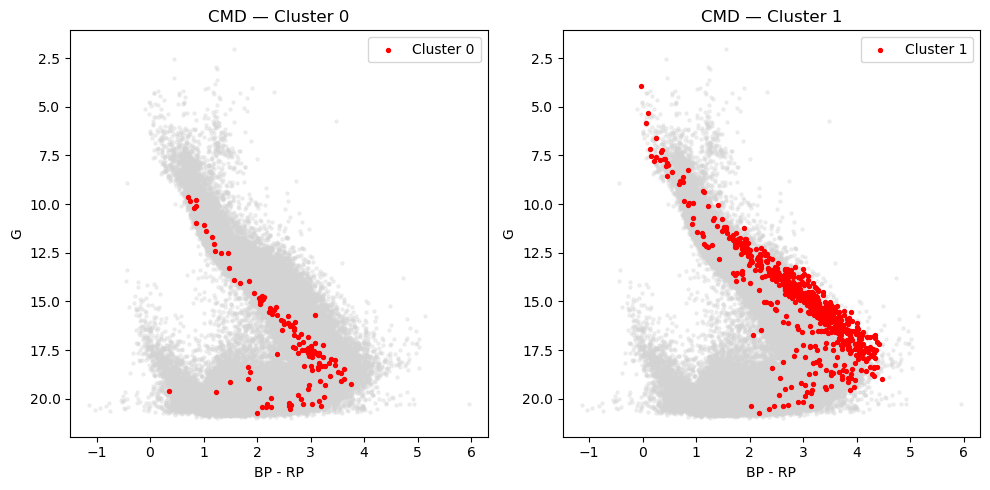

Silhouette promedio: 0.3002


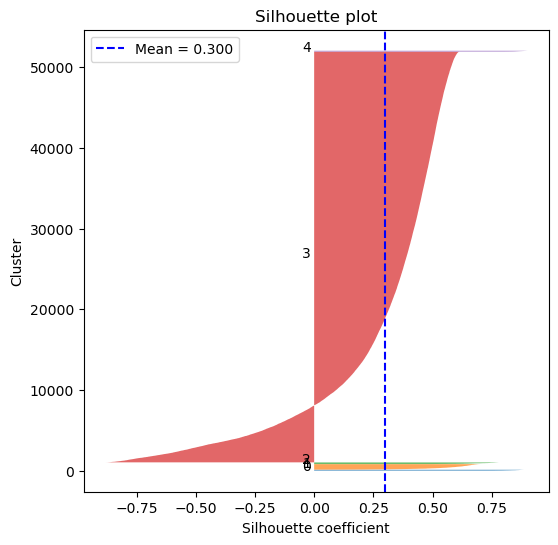

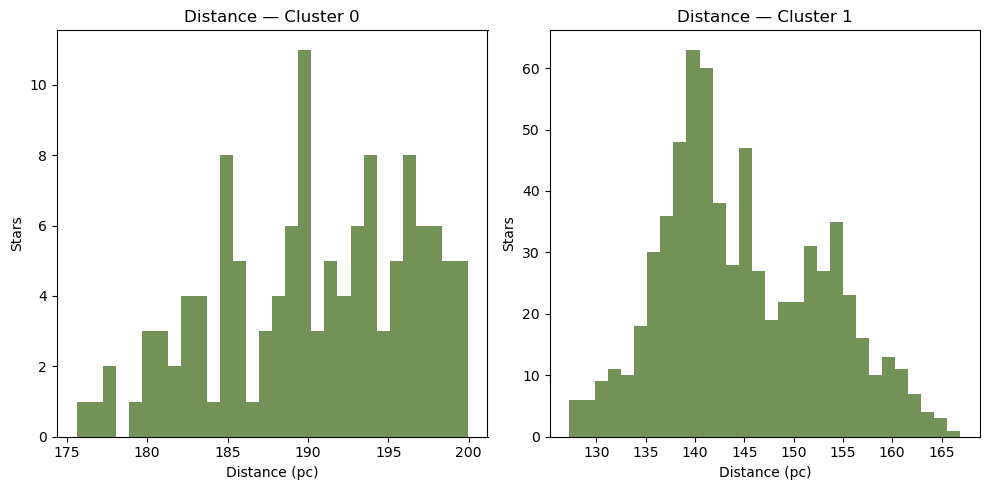


Región 45 RA: [225.00, 270.00] | DEC: [0.01, 22.49]
Clusters encontrados:
  Ruido: 44655
  Cluster 0: 101
  Cluster 1: 8823
  Cluster 2: 115


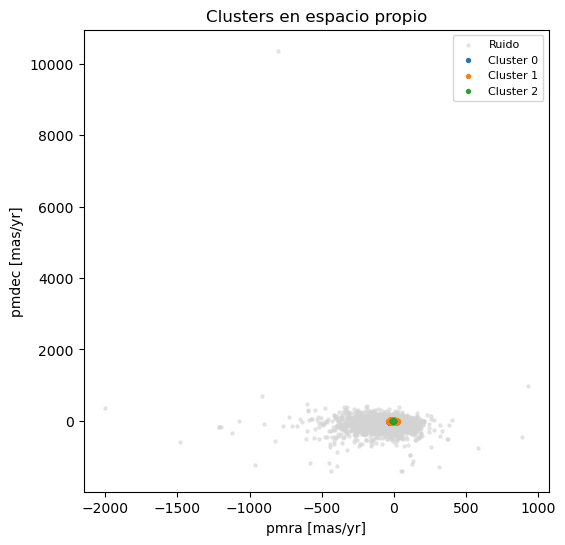

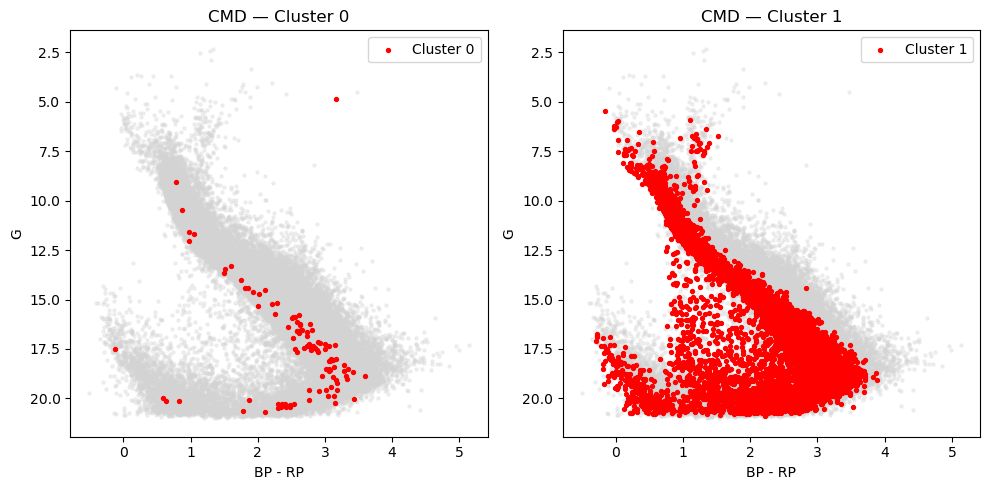

Silhouette promedio: 0.1533


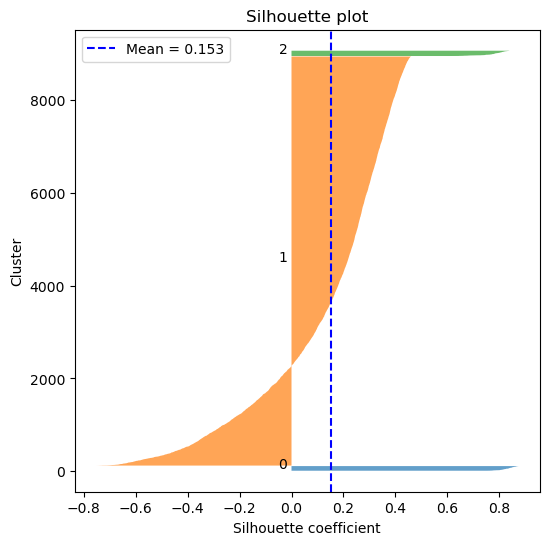

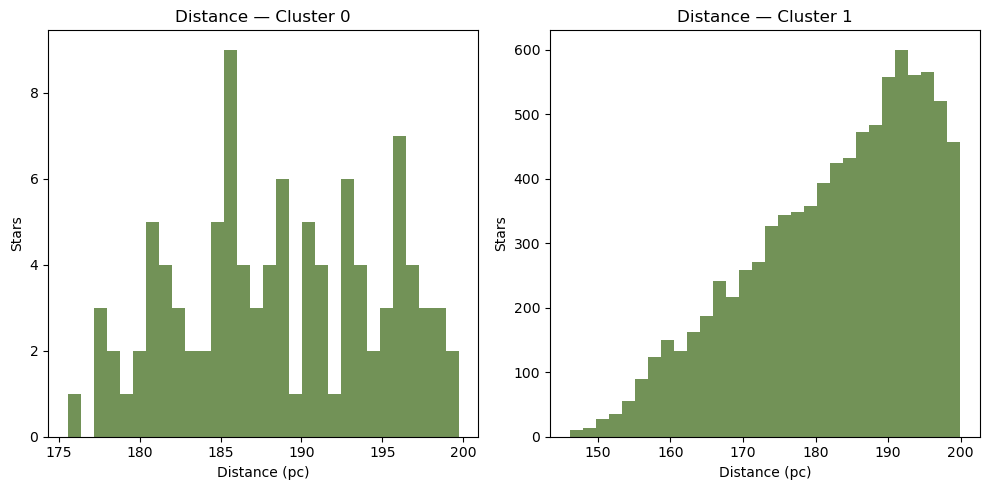


Región 46 RA: [225.00, 270.00] | DEC: [22.49, 44.98]
Clusters encontrados:
  Ruido: 38609
  Cluster 0: 2833
  Cluster 1: 149


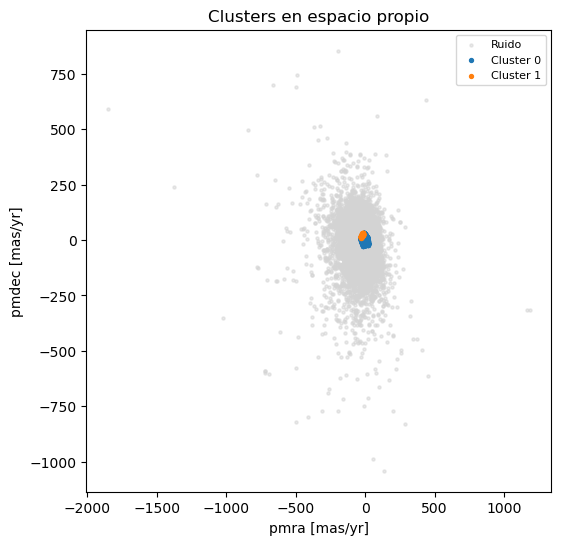

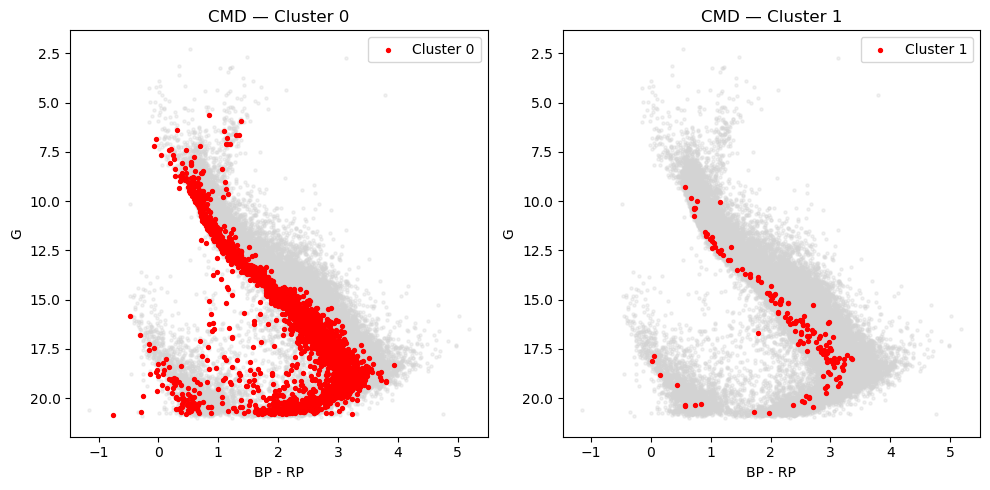

Silhouette promedio: 0.2698


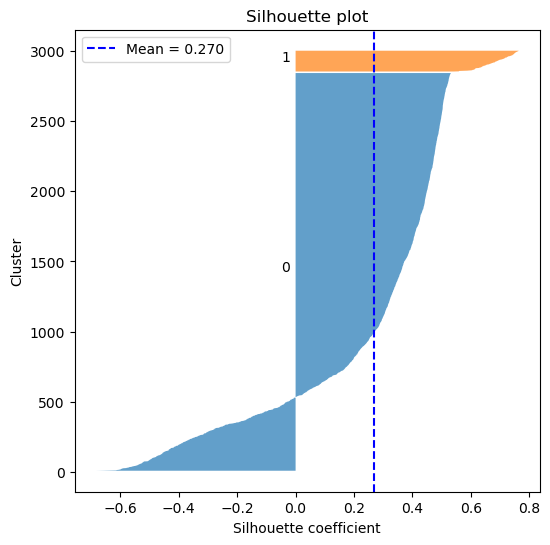

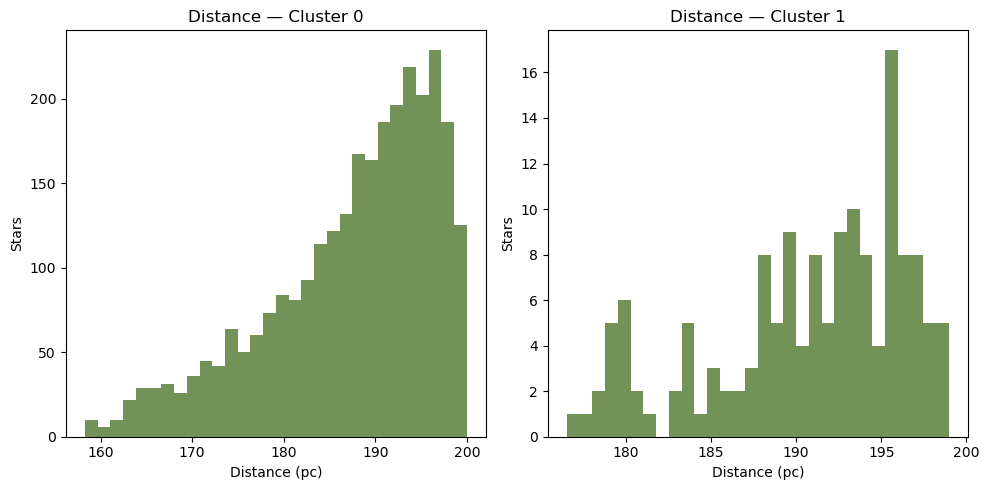


Región 47 RA: [225.00, 270.00] | DEC: [44.98, 67.46]
Clusters encontrados:
  Ruido: 18007
  Cluster 0: 8704
  Cluster 1: 110


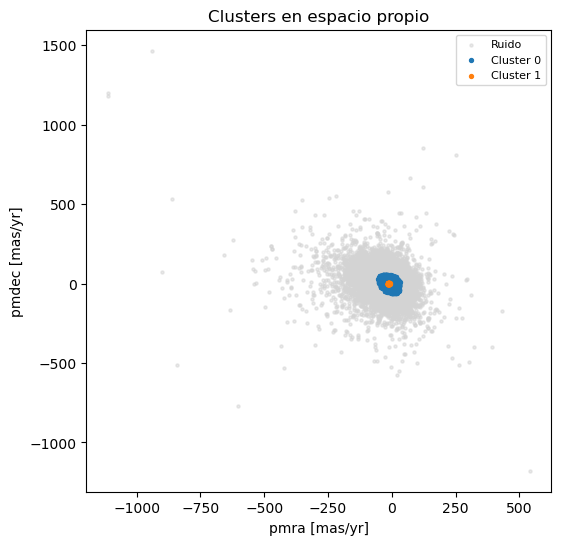

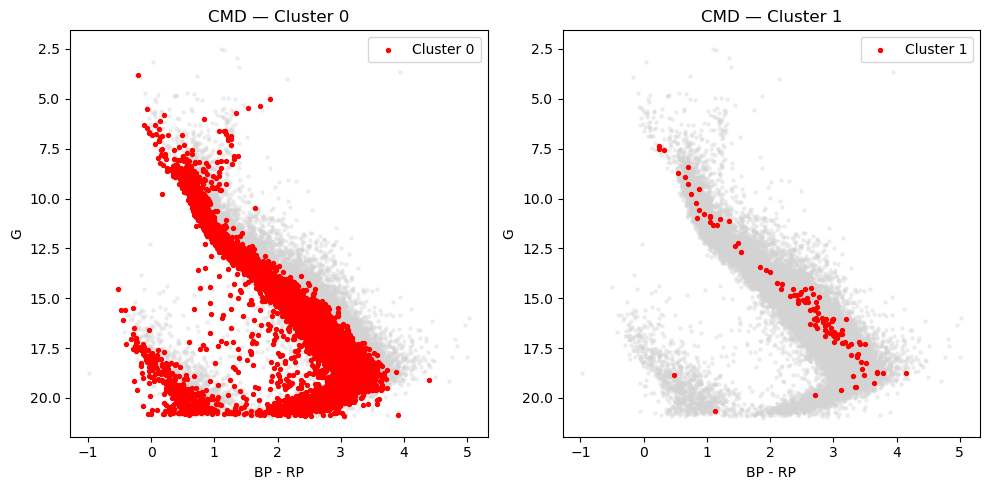

Silhouette promedio: 0.3911


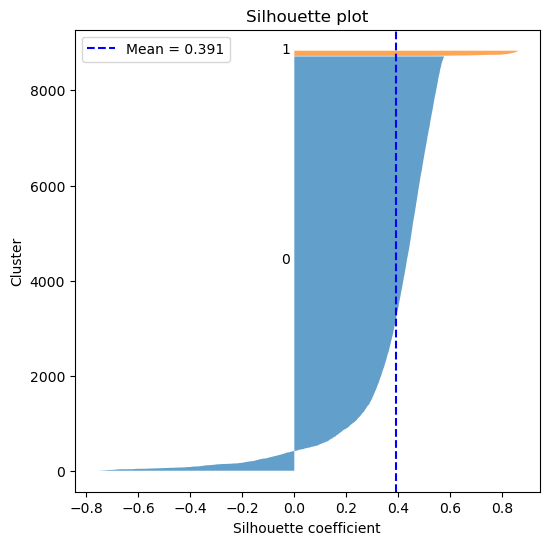

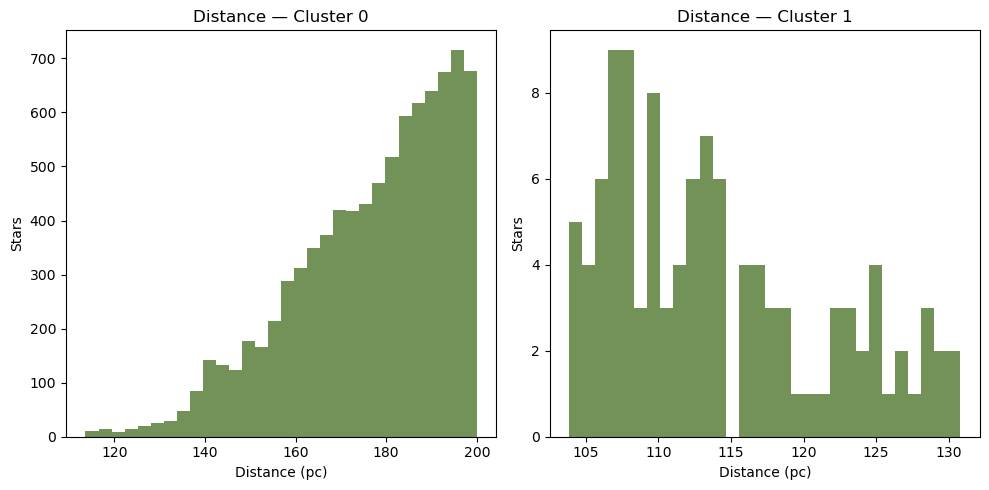


Región 48 RA: [225.00, 270.00] | DEC: [67.46, 89.95]
Clusters encontrados:
  Ruido: 9189
  Cluster 0: 478
  Cluster 1: 276


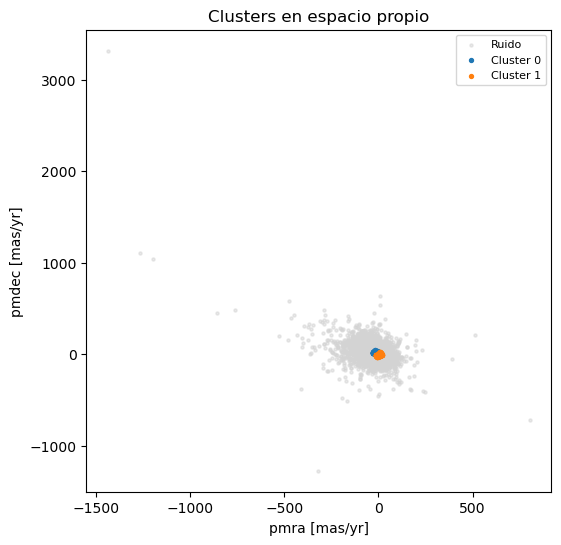

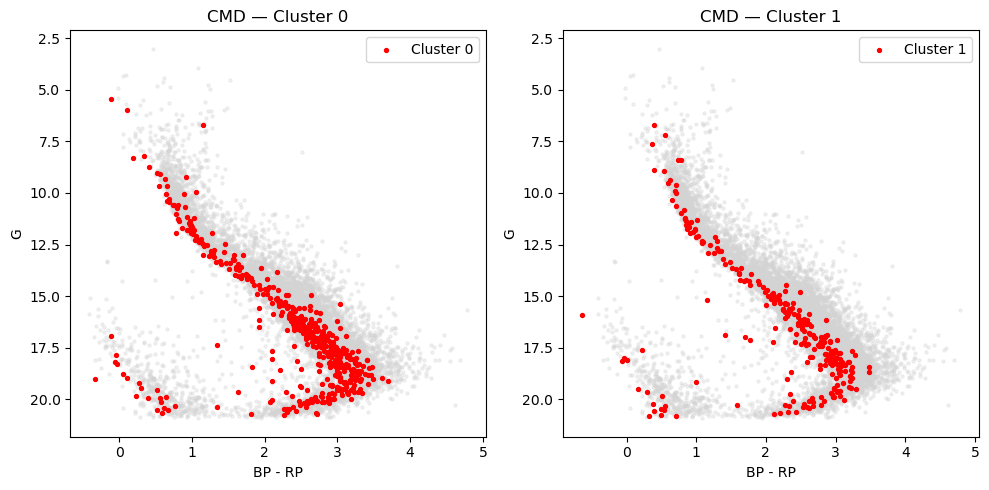

Silhouette promedio: 0.4123


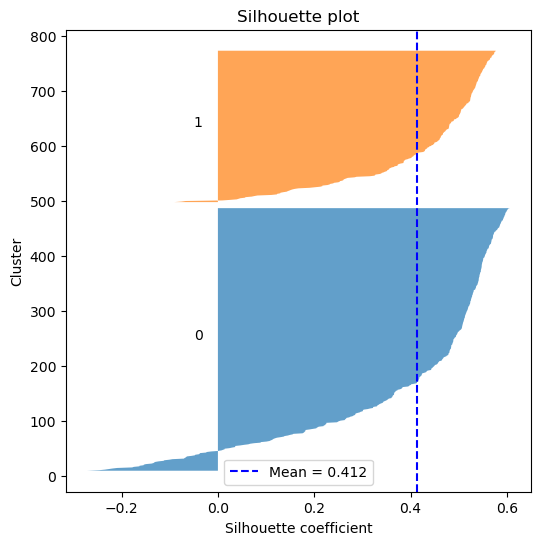

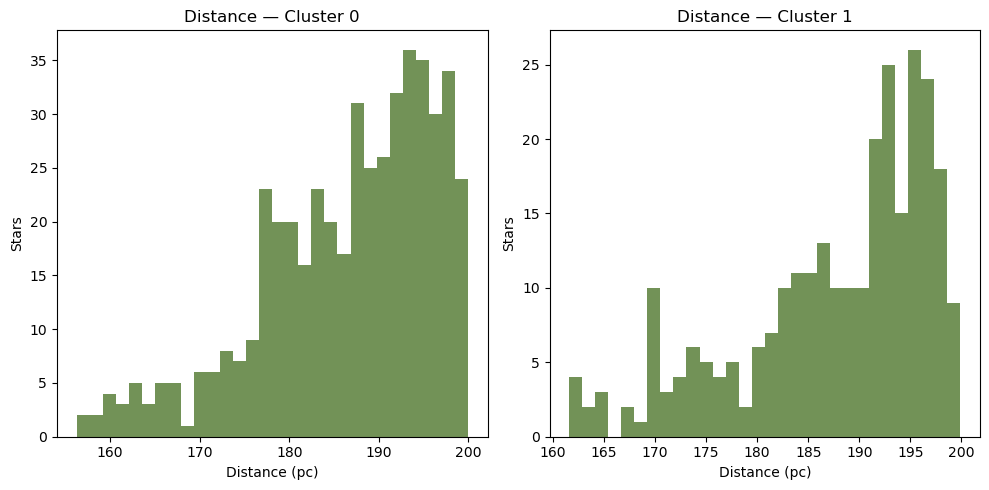


Región 49 RA: [270.00, 315.00] | DEC: [-89.93, -67.45]
Clusters encontrados:
  Ruido: 11741


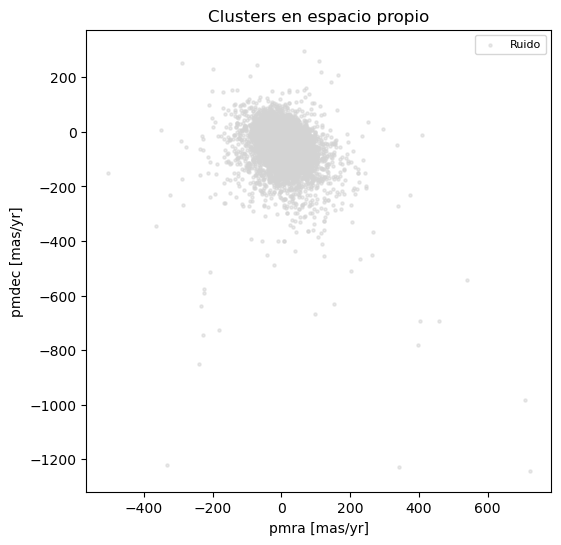

No se encontraron clusters en esta región (solo ruido).

Región 50 RA: [270.00, 315.00] | DEC: [-67.45, -44.96]
Clusters encontrados:
  Ruido: 24925
  Cluster 0: 10500
  Cluster 1: 120


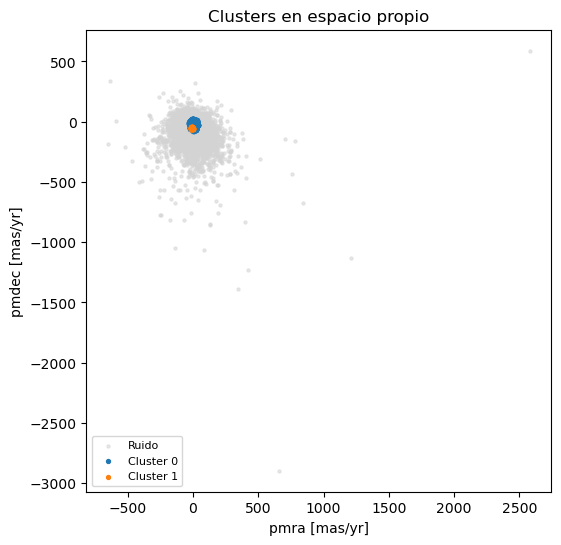

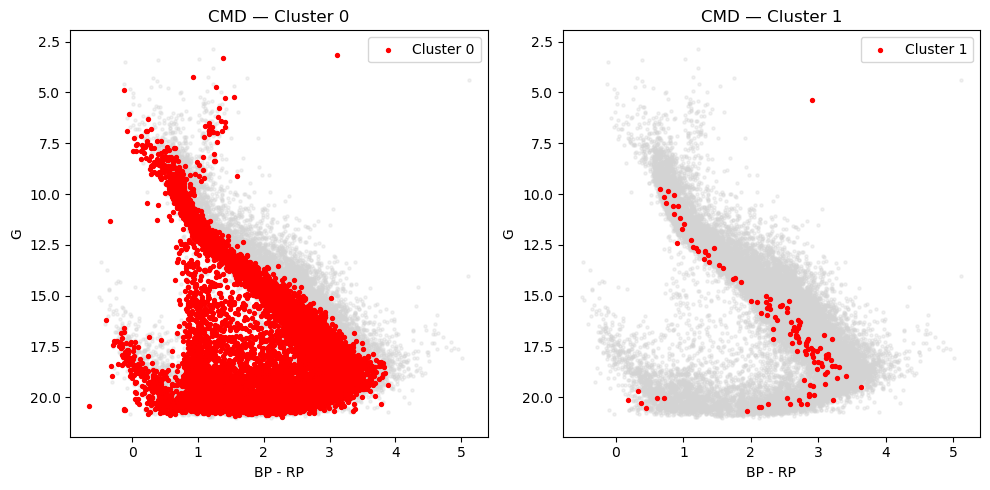

Silhouette promedio: 0.2857


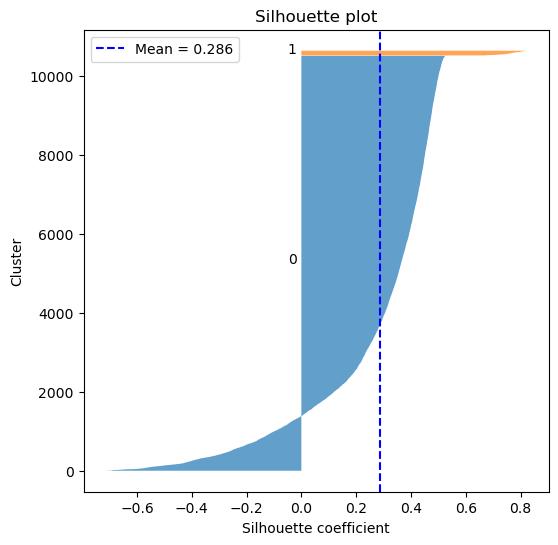

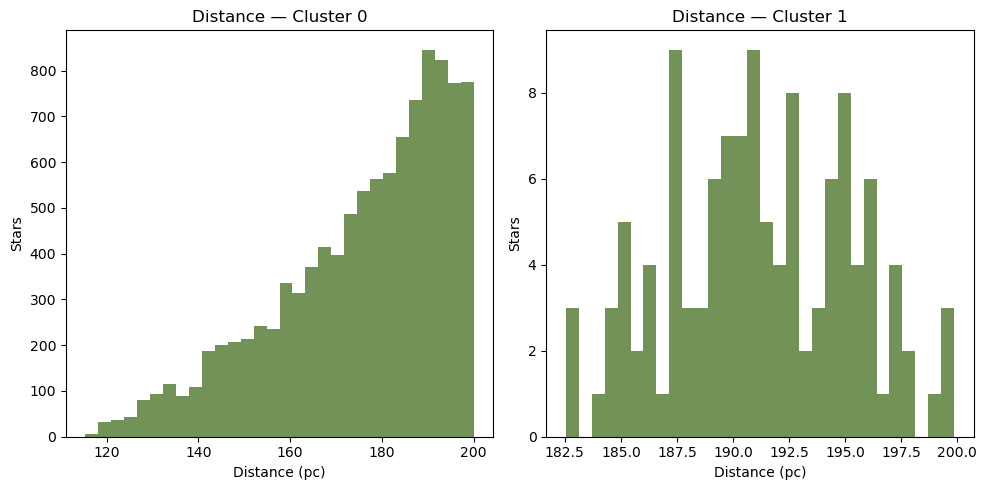

In [ ]:
centinela = 0

num_regiones_clusters=0

for i in range(8):
    for j in range(8):
        if centinela+1 <44:
            centinela+=1
            print(centinela)
        else: 
            # Definir región
            ra_min, ra_max = ra_bins[i], ra_bins[i+1]
            dec_min, dec_max = dec_bins[j], dec_bins[j+1]

            mask = ((ra >= ra_min) & (ra < ra_max) & (dec >= dec_min) & (dec < dec_max))

            # Saltar regiones vacías o muy pequeñas
            if np.sum(mask) < 100:
                continue

            # Extraer datos para la región
            pmra_i = pmra[mask]
            pmdec_i = pmdec[mask]
            parallax_i = parallax[mask]
            g_mag_i = g_mag[mask]
            bp_rp_i = bp_rp[mask]

            # HDBSCAN
            data_i = np.column_stack((pmra_i, pmdec_i, parallax_i))
            data_i = RobustScaler().fit_transform(data_i)

            hd = HDBSCAN(min_cluster_size=100, min_samples=6)
            labels = hd.fit_predict(data_i)

            # Resumen de clusters por region
            unique, counts = np.unique(labels, return_counts=True)

            centinela += 1

            print("\n" + "="*60)
            print(f"Región {centinela} RA: [{ra_min:.2f}, {ra_max:.2f}] | DEC: [{dec_min:.2f}, {dec_max:.2f}]")
            print("Clusters encontrados:")
            for u, c in zip(unique, counts):
                if u == -1:
                    print(f"  Ruido: {c}")
                else:
                    print(f"  Cluster {u}: {c}")
        
            # Espacio de movimientos propios

            plt.figure(figsize=(6,6))

            noise = labels == -1
            plt.scatter(pmra_i[noise], pmdec_i[noise], s=5, c='lightgray', alpha=0.5, label='Ruido')

            for c in np.unique(labels[labels != -1]):
                mask_c = labels == c
                plt.scatter(pmra_i[mask_c], pmdec_i[mask_c], s=8, label=f'Cluster {c}')

            plt.xlabel('pmra [mas/yr]')
            plt.ylabel('pmdec [mas/yr]')
            plt.title('Clusters en espacio propio')
            plt.legend(fontsize=8)
            plt.show()

            # CMDs por cluster

            clusters = np.unique(labels[labels != -1])

            if len(clusters) == 0:
                print("No se encontraron clusters en esta región (solo ruido).")
            else:
                clusters = clusters[:2]  # limitar a 2
                num_regiones_clusters += 1

                fig, axes = plt.subplots(1, len(clusters), figsize=(5*len(clusters),5))

                if len(clusters) == 1:
                    axes = [axes]

                for idx, c in enumerate(clusters):
                    ax = axes[idx]
                    mask_c = labels == c

                    ax.scatter(bp_rp_i[labels == -1], g_mag_i[labels == -1], s=5, color='lightgray', alpha=0.3)
                    ax.scatter(bp_rp_i[mask_c], g_mag_i[mask_c], s=8, color='red', label=f'Cluster {c}')

                    ax.set_title(f'CMD — Cluster {c}')
                    ax.set_xlabel('BP - RP')
                    ax.set_ylabel('G')
                    ax.legend()

                # invertir eje correctamente
                ymin, ymax = axes[0].get_ylim()
                for ax in axes:
                    ax.set_ylim(ymax, ymin)

                plt.tight_layout()
                plt.show()

            # Silhouette Score

            mask_valid = labels != -1

            if np.sum(mask_valid) > 50 and len(np.unique(labels[mask_valid])) > 1:

                X = data_i[mask_valid]
                labels_clean = labels[mask_valid]

                sil_vals = silhouette_samples(X, labels_clean)
                sil_avg = silhouette_score(X, labels_clean)

                print(f"Silhouette promedio: {sil_avg:.4f}")
                plt.figure(figsize=(6,6))

                y_lower = 10
                for c in np.unique(labels_clean):
                    sil_c = sil_vals[labels_clean == c]
                    sil_c.sort()

                    size = len(sil_c)
                    y_upper = y_lower + size

                    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_c, alpha=0.7)
                    plt.text(-0.05, y_lower + size/2, str(c))

                    y_lower = y_upper + 10

                plt.axvline(x=sil_avg, linestyle="--", color="blue", label=f"Mean = {sil_avg:.3f}")

                plt.title("Silhouette plot")
                plt.xlabel("Silhouette coefficient")
                plt.ylabel("Cluster")
                plt.legend()
                plt.show()

            # Distance histograms

            clusters = np.unique(labels[labels != -1])[:2]
            if len(clusters) == 0:
                continue

            else:
                fig, axes = plt.subplots(1, len(clusters), figsize=(5*len(clusters),5))

                if len(clusters) == 1:
                    axes = [axes]

                for idx, c in enumerate(clusters):
                    ax = axes[idx]
                    mask_c = labels == c

                    distances = 1000 / parallax_i[mask_c]

                    ax.hist(distances, bins=30, color='#4f772d', alpha=0.8)
                    ax.set_title(f'Distance — Cluster {c}')
                    ax.set_xlabel('Distance (pc)')
                    ax.set_ylabel('Stars')

                plt.tight_layout()
                plt.show()

In [ ]:
#Número de regiones con clusters encontrados
print(num_regiones_clusters)


Región 13 | RA: [45.00, 90.00] | DEC: [0.01, 22.49]
Número de estrellas en la región: 56391
Clusters encontrados:
  Ruido: 6097
  Cluster 0: 49941
  Cluster 1: 353


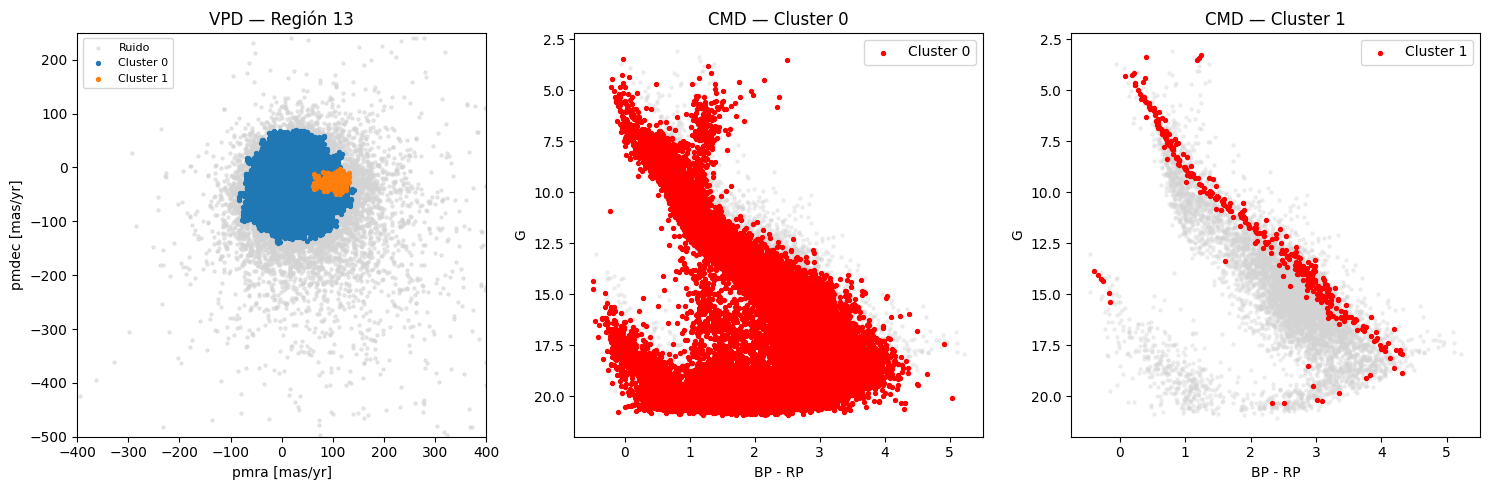

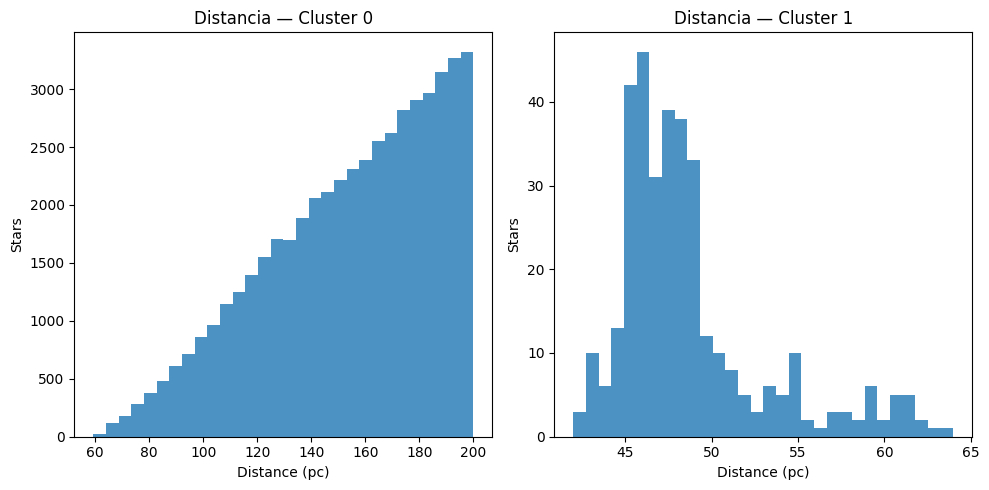


Región 15 | RA: [45.00, 90.00] | DEC: [44.98, 67.46]
Número de estrellas en la región: 36068
Clusters encontrados:
  Ruido: 32482
  Cluster 0: 1365
  Cluster 1: 2013
  Cluster 2: 208


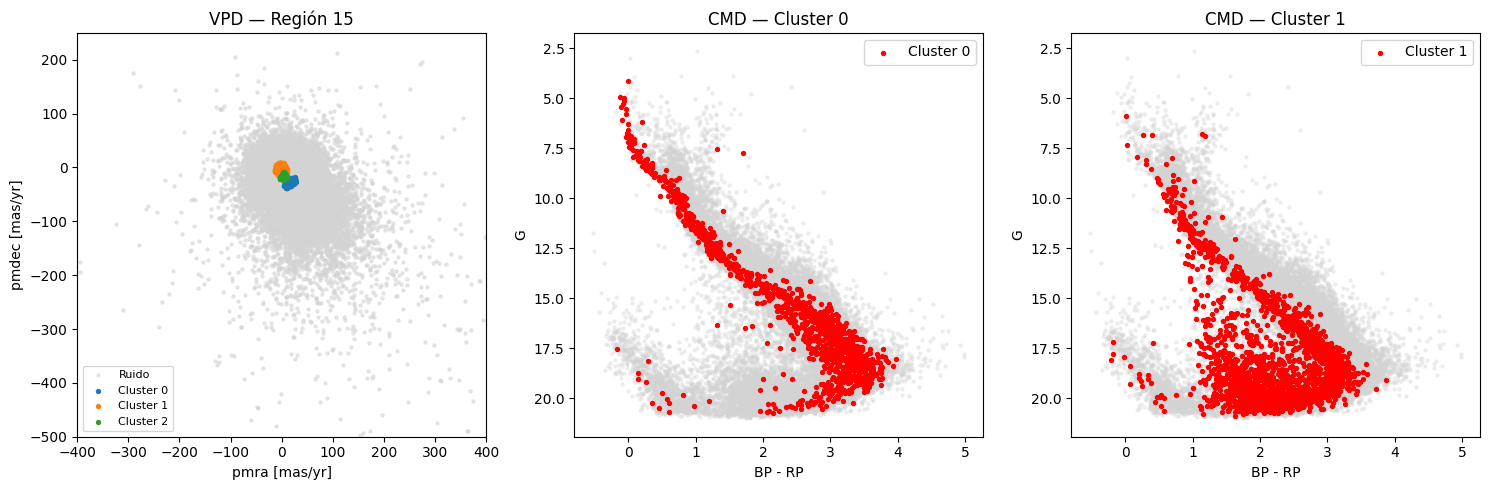

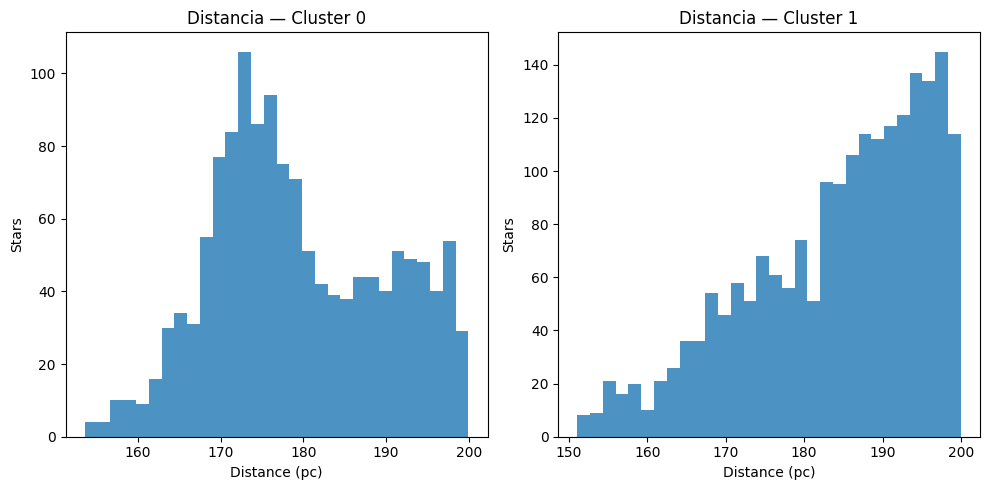


Región 18 | RA: [90.00, 135.00] | DEC: [-67.45, -44.96]
Número de estrellas en la región: 33717
Clusters encontrados:
  Ruido: 30760
  Cluster 0: 402
  Cluster 1: 2432
  Cluster 2: 123


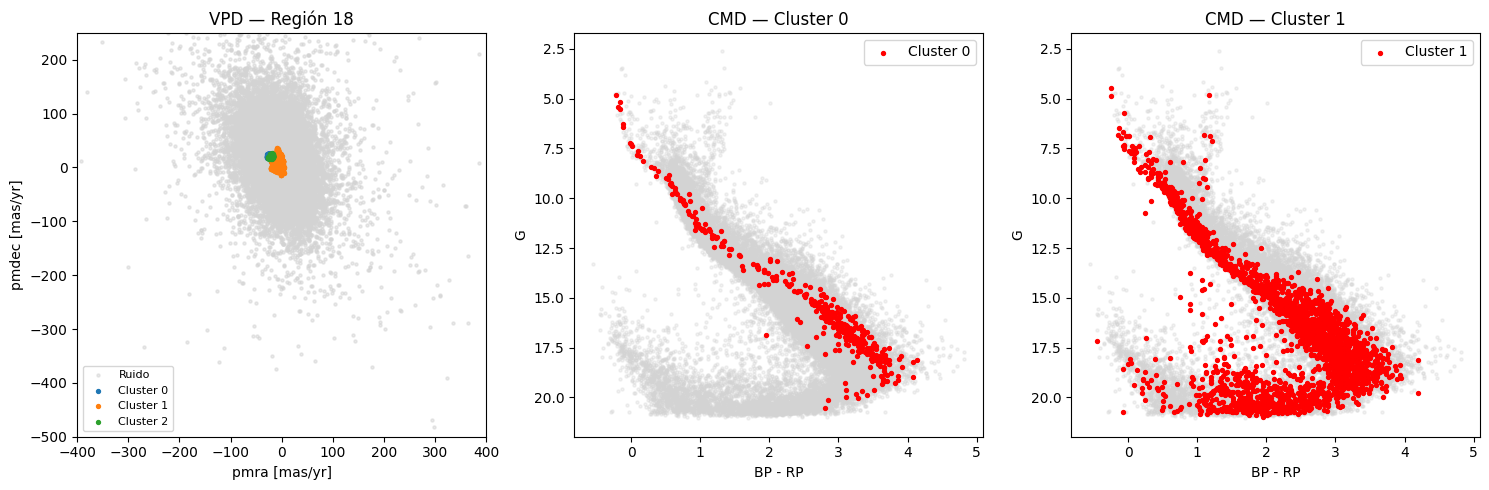

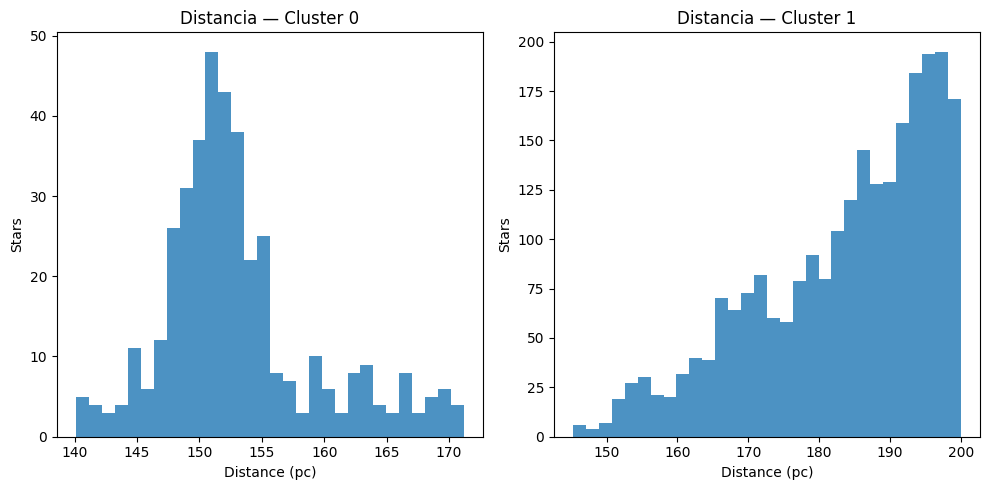


Región 21 | RA: [90.00, 135.00] | DEC: [0.01, 22.49]
Número de estrellas en la región: 54931
Clusters encontrados:
  Ruido: 45846
  Cluster 0: 7890
  Cluster 1: 1195


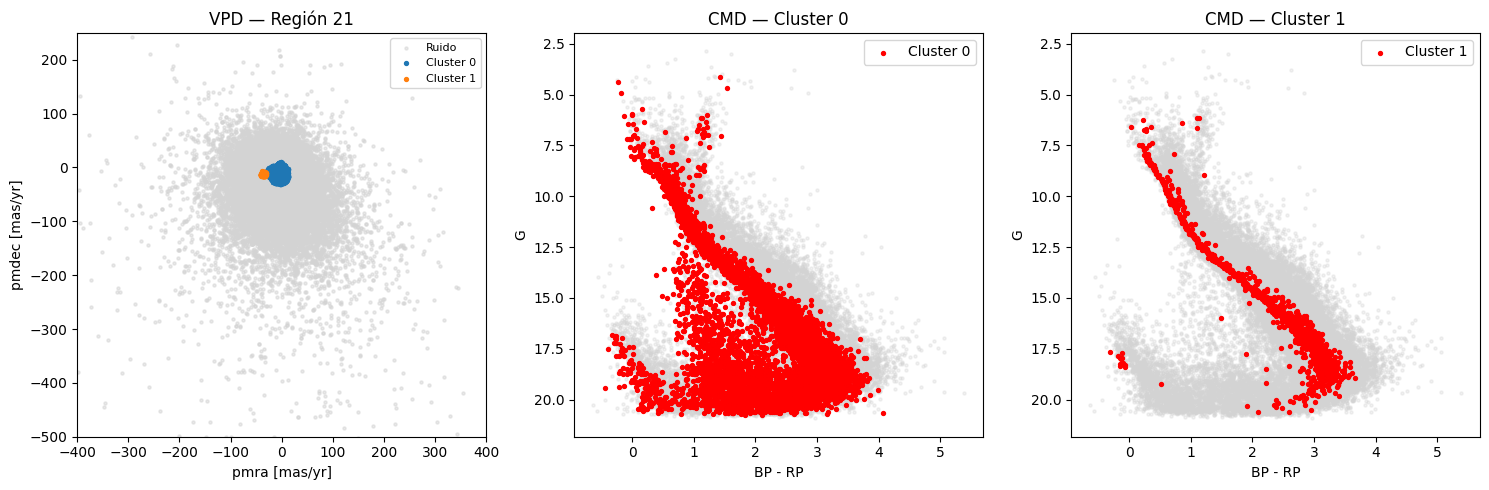

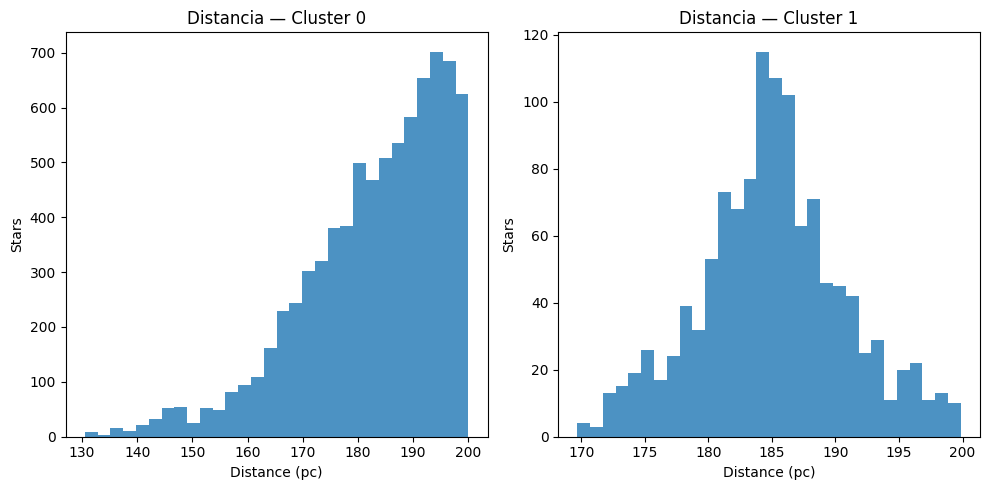


Región 27 | RA: [135.00, 180.00] | DEC: [-44.96, -22.48]
Número de estrellas en la región: 48235
Clusters encontrados:
  Ruido: 44496
  Cluster 0: 3332
  Cluster 1: 407


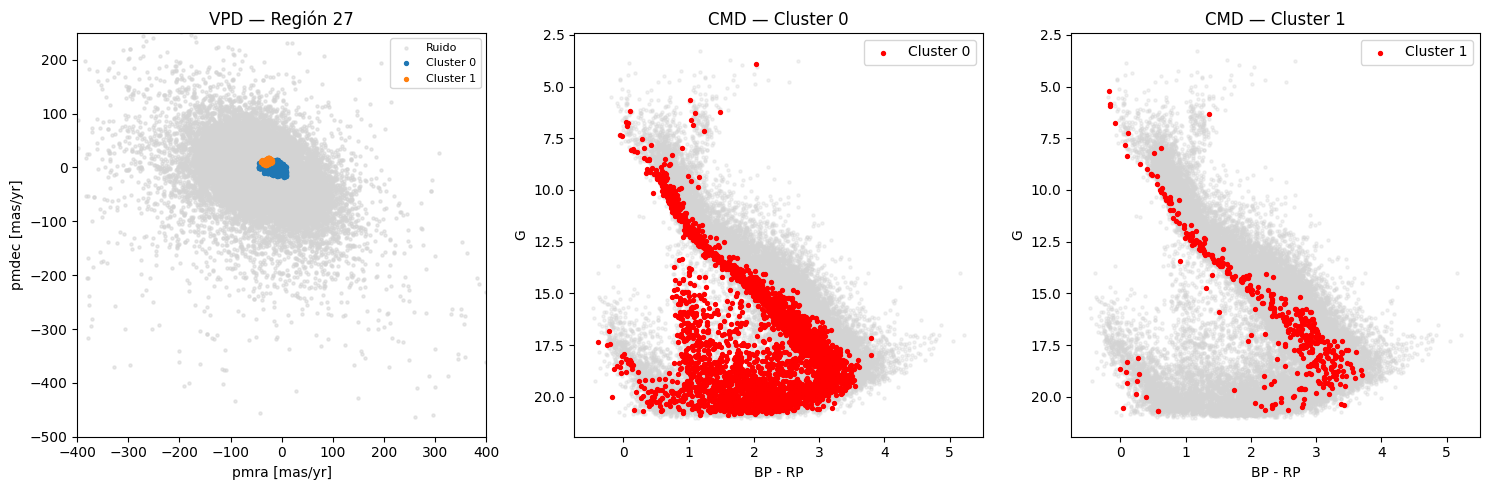

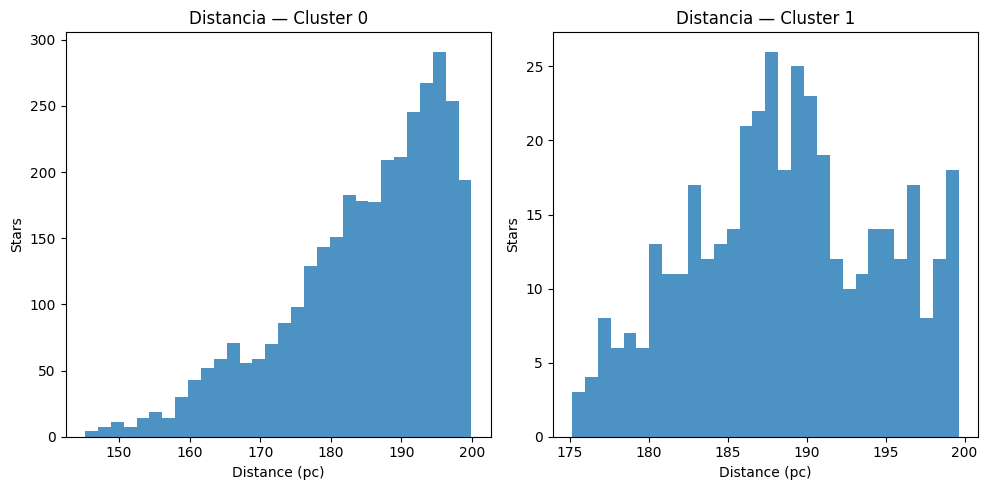


Región 38 | RA: [180.00, 225.00] | DEC: [22.49, 44.98]
Número de estrellas en la región: 35506
Clusters encontrados:
  Ruido: 16070
  Cluster 0: 19140
  Cluster 1: 296


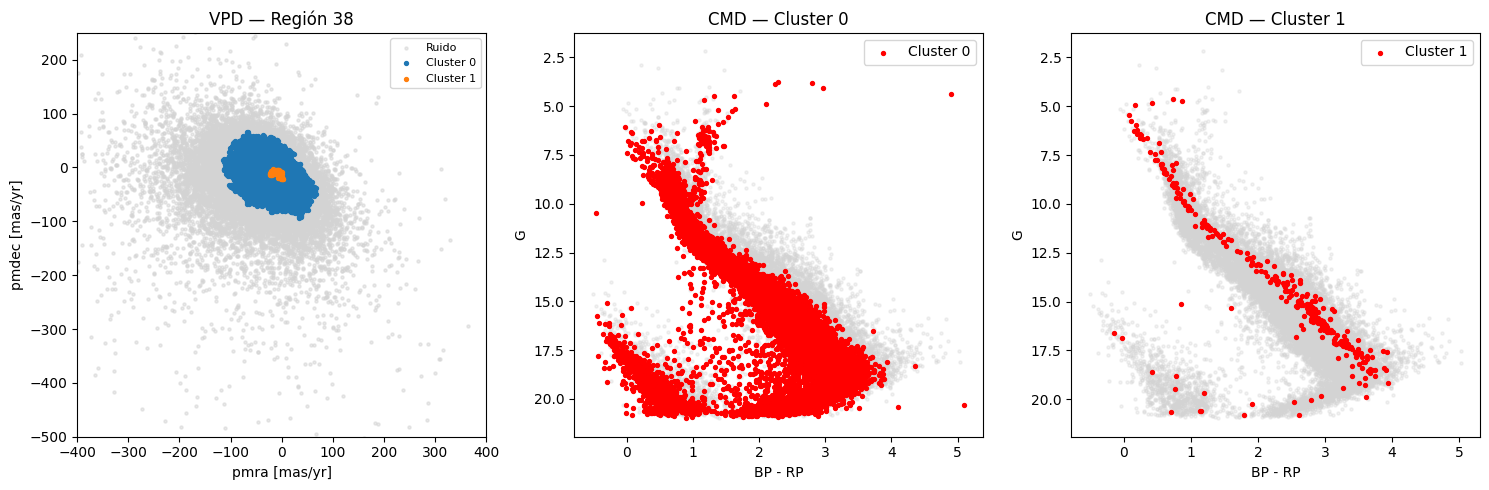

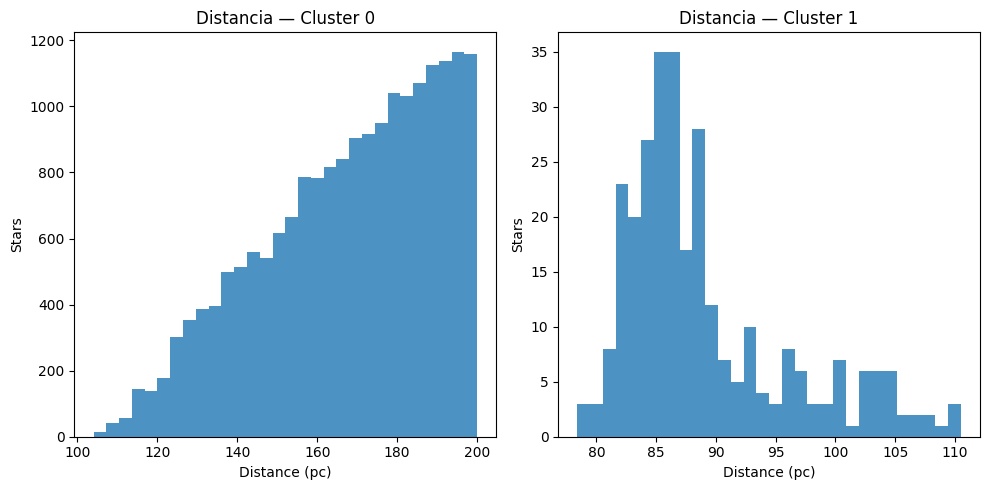


Región 39 | RA: [180.00, 225.00] | DEC: [44.98, 67.46]
Número de estrellas en la región: 24651
Clusters encontrados:
  Ruido: 12232
  Cluster 0: 12217
  Cluster 1: 202


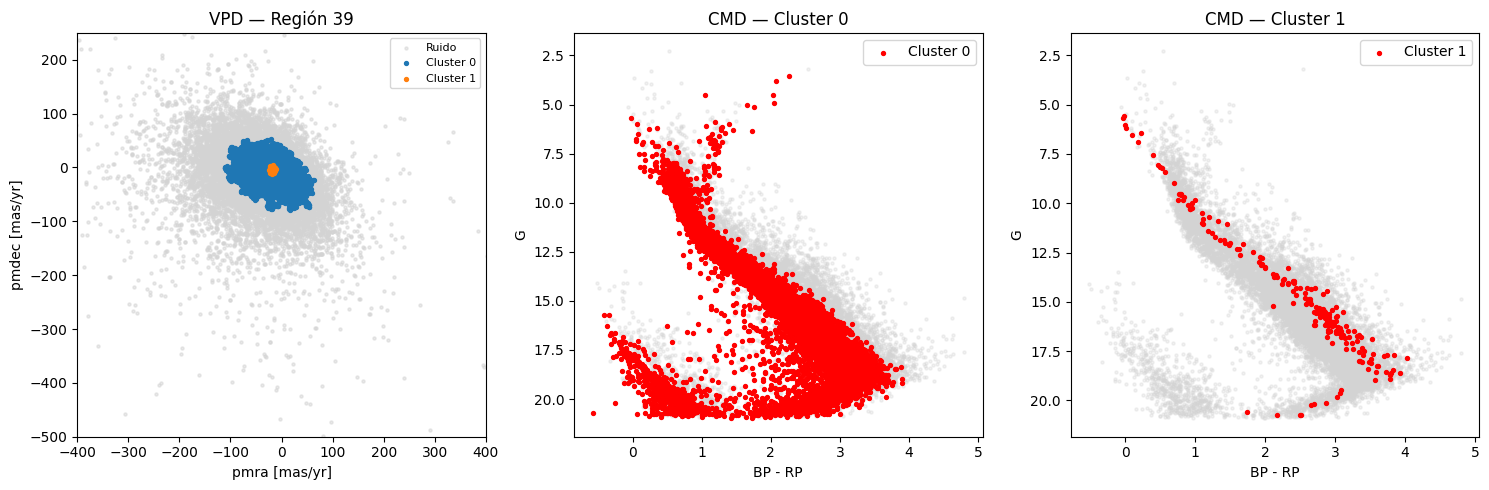

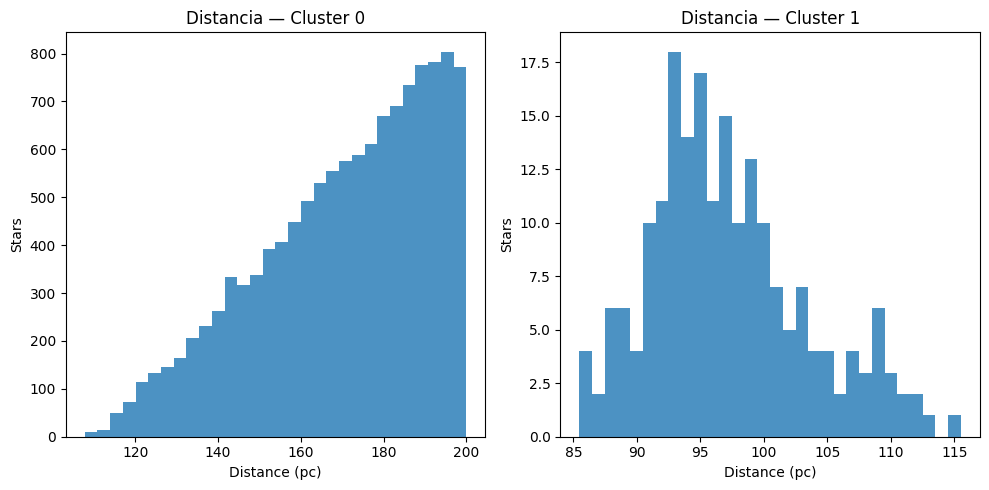

In [ ]:
#Por inspección visual, seleccionamos las regiones que cumplen condiciones de Cúmulos Abiertos.
regiones = [13, 15, 18, 21, 27, 38,  39]


# Regiones a analizar
regiones = [13, 15, 18, 21, 27, 38,  39]
todas_las_regiones = []
centinela = 0
for i in range(8):
    for j in range(8):
        centinela += 1
        ra_min, ra_max = ra_bins[i], ra_bins[i+1]
        dec_min, dec_max = dec_bins[j], dec_bins[j+1]
        todas_las_regiones.append({
            "id": centinela,
            "i": i,
            "j": j,
            "ra_min": ra_min,
            "ra_max": ra_max,
            "dec_min": dec_min,
            "dec_max": dec_max
        })

# Procesar solo las regiones solicitadas
for reg_id in regiones:
    region = next((r for r in todas_las_regiones if r["id"] == reg_id), None)
    if region is None:
        print(f"Región {reg_id} no encontrada.")
        continue

    ra_min, ra_max = region["ra_min"], region["ra_max"]
    dec_min, dec_max = region["dec_min"], region["dec_max"]

    mask = ((ra >= ra_min) & (ra < ra_max) &
            (dec >= dec_min) & (dec < dec_max))

    n_obj = np.sum(mask)
    print("\n" + "="*70)
    print(f"Región {reg_id} | RA: [{ra_min:.2f}, {ra_max:.2f}] | DEC: [{dec_min:.2f}, {dec_max:.2f}]")
    print(f"Número de estrellas en la región: {n_obj}")

    if n_obj < 100:
        print("Región muy pequeña o vacía. Se omite.")
        continue

    # Extraer datos
    pmra_i = pmra[mask]
    pmdec_i = pmdec[mask]
    parallax_i = parallax[mask]
    g_mag_i = g_mag[mask]
    bp_rp_i = bp_rp[mask]

    # HDBSCAN en (pmra, pmdec, parallax)
    data_i = np.column_stack((pmra_i, pmdec_i, parallax_i))
    data_i = RobustScaler().fit_transform(data_i)

    hd = HDBSCAN(min_cluster_size=100, min_samples=6)
    labels = hd.fit_predict(data_i)

    unique, counts = np.unique(labels, return_counts=True)

    print("Clusters encontrados:")
    for u, c in zip(unique, counts):
        if u == -1:
            print(f"  Ruido: {c}")
        else:
            print(f"  Cluster {u}: {c}")

    # Elegir hasta 2 clusters para CMD e histograma
    clusters = np.unique(labels[labels != -1])[:2]

    # Figura general: VPD, CMD(s), histograma(s)
    n_panels = 3
    fig, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 5))

    if n_panels == 1:
        axes = [axes]

    ax_idx = 0

    # -------------------------
    # VPD
    # -------------------------
    ax = axes[ax_idx]
    ax_idx += 1

    noise = labels == -1
    ax.scatter(pmra_i[noise], pmdec_i[noise], s=5, c='lightgray', alpha=0.5, label='Ruido')

    for c in np.unique(labels[labels != -1]):
        mask_c = labels == c
        ax.scatter(pmra_i[mask_c], pmdec_i[mask_c], s=8, label=f'Cluster {c}')

    ax.set_xlabel('pmra [mas/yr]')
    ax.set_ylabel('pmdec [mas/yr]')
    ax.set_title(f'VPD — Región {reg_id}')
    ax.legend(fontsize=8)
    ax.set_ylim(-500,250)
    ax.set_xlim(-400,400)

    # -------------------------
    # CMDs por cluster
    # -------------------------
    if len(clusters) == 0:
        ax = axes[ax_idx]
        ax_idx += 1
        ax.axis("off")
        ax.text(0.5, 0.5, "Solo ruido\n(no hay clusters)", ha="center", va="center", fontsize=12)

        ax = axes[ax_idx]
        ax.axis("off")
        ax.text(0.5, 0.5, "Sin histograma\n(no hay clusters)", ha="center", va="center", fontsize=12)

    else:
        for c in clusters:
            ax = axes[ax_idx]
            ax_idx += 1

            mask_c = labels == c
            ax.scatter(bp_rp_i[labels == -1], g_mag_i[labels == -1],
                       s=5, color='lightgray', alpha=0.3)
            ax.scatter(bp_rp_i[mask_c], g_mag_i[mask_c],
                       s=8, color='red', label=f'Cluster {c}')

            ax.set_title(f'CMD — Cluster {c}')
            ax.set_xlabel('BP - RP')
            ax.set_ylabel('G')
            ax.legend()

    # Invertir eje Y en todos los CMDs
    for ax in axes[1:]:
        if ax.has_data():
            ymin, ymax = ax.get_ylim()
            ax.set_ylim(ymax, ymin)

    plt.tight_layout()
    plt.show()

    # -------------------------
    # Histograma de distancias
    # -------------------------
    if len(clusters) > 0:
        fig, axes = plt.subplots(1, len(clusters), figsize=(5*len(clusters), 5))
        if len(clusters) == 1:
            axes = [axes]

        for idx, c in enumerate(clusters):
            ax = axes[idx]
            mask_c = labels == c

            # Distancia en parsec: d = 1000 / parallax(mas)
            par_c = parallax_i[mask_c]
            par_c = par_c[par_c > 0]  # evitar parallax no positiva

            distances = 1000.0 / par_c

            ax.hist(distances, bins=30, alpha=0.8)
            ax.set_title(f'Distancia — Cluster {c}')
            ax.set_xlabel('Distance (pc)')
            ax.set_ylabel('Stars')

        plt.tight_layout()
        plt.show()

In [ ]:
def calcular_centros_clusters(ra, dec, pmra, pmdec, parallax,
                              ra_bins, dec_bins,
                              regiones_objetivo,
                              min_cluster_size=100,
                              min_samples=6):

    resultados = []

    regiones = []
    centinela = 0
    for i in range(8):
        for j in range(8):
            centinela += 1
            regiones.append({
                "id": centinela,
                "ra_min": ra_bins[i],
                "ra_max": ra_bins[i+1],
                "dec_min": dec_bins[j],
                "dec_max": dec_bins[j+1]
            })

    for reg_id in regiones_objetivo:
        region = next((r for r in regiones if r["id"] == reg_id), None)
        if region is None:
            print(f"Región {reg_id} no encontrada.")
            continue

        ra_min, ra_max = region["ra_min"], region["ra_max"]
        dec_min, dec_max = region["dec_min"], region["dec_max"]

        mask = ((ra >= ra_min) & (ra < ra_max) &
                (dec >= dec_min) & (dec < dec_max))

        if np.sum(mask) < 100:
            print(f"Región {reg_id}: muy pocos datos, se omite.")
            continue

        ra_i = ra[mask]
        dec_i = dec[mask]
        pmra_i = pmra[mask]
        pmdec_i = pmdec[mask]
        parallax_i = parallax[mask]

        # Clustering
        data_i = np.column_stack((pmra_i, pmdec_i, parallax_i))
        data_i = RobustScaler().fit_transform(data_i)

        hd = HDBSCAN(min_cluster_size=min_cluster_size,
                     min_samples=min_samples)
        labels = hd.fit_predict(data_i)

        clusters = np.unique(labels[labels != -1])

        print("\n" + "="*60)
        print(f"Región {reg_id}")
        print(f"Clusters encontrados: {len(clusters)}")

        if len(clusters) == 0:
            print("  Solo ruido.")
            continue

        for c in clusters:
            mask_c = labels == c

            # Centroide en coordenadas celestes
            ra_center = np.median(ra_i[mask_c])
            dec_center = np.median(dec_i[mask_c])

            resultados.append({
                "region": reg_id,
                "cluster": int(c),
                "ra_center": ra_center,
                "dec_center": dec_center,
                "n_stars": np.sum(mask_c)
            })

            print(f"  Cluster {c}:")
            print(f"    Centro RA  = {ra_center:.4f}")
            print(f"    Centro Dec = {dec_center:.4f}")
            print(f"    N estrellas = {np.sum(mask_c)}")

    return resultados

centros = calcular_centros_clusters(
    ra, dec, pmra, pmdec, parallax,
    ra_bins, dec_bins,
    regiones
)


df_centros = pd.DataFrame(centros)
df_centros

#Hyades:       RA = 66.75°, Dec = +15.87°, d = 47 pc
#Alpha Persei: RA = 51.50°, Dec = +49.12°, d = 175 pc
#IC 2391:      RA = 130.00°, Dec = −53.00°, d = 150 pc
#Coma:         RA = 186.25°, Dec = +26.10°, d = 86 pc
#NGC 2451:     RA = 116.25°, Dec = −38.20°, d = 190 pc

#IC 2602:      RA = 160.75°, Dec = −64.40°, d = 150 pc
#Melotte 186:  RA = 81.00°, Dec = +33.10°, d = 160 pc
#Messier 44:   RA = 130.00°, Dec = +19.70°, d = 187 pc
#Messier 45:   RA = 56.75°, Dec = +24.12°, d = 136 pc


Región 13
Clusters encontrados: 2
  Cluster 0:
    Centro RA  = 69.1750
    Centro Dec = 11.5447
    N estrellas = 49941
  Cluster 1:
    Centro RA  = 67.2095
    Centro Dec = 16.3568
    N estrellas = 353

Región 15
Clusters encontrados: 3
  Cluster 0:
    Centro RA  = 52.7456
    Centro Dec = 49.3838
    N estrellas = 1365
  Cluster 1:
    Centro RA  = 66.1214
    Centro Dec = 54.0306
    N estrellas = 2013
  Cluster 2:
    Centro RA  = 68.0995
    Centro Dec = 53.8404
    N estrellas = 208

Región 18
Clusters encontrados: 3
  Cluster 0:
    Centro RA  = 130.1211
    Centro Dec = -52.9382
    N estrellas = 402
  Cluster 1:
    Centro RA  = 116.3600
    Centro Dec = -52.1922
    N estrellas = 2432
  Cluster 2:
    Centro RA  = 123.1635
    Centro Dec = -51.7777
    N estrellas = 123

Región 21
Clusters encontrados: 2
  Cluster 0:
    Centro RA  = 106.2874
    Centro Dec = 11.0227
    N estrellas = 7890
  Cluster 1:
    Centro RA  = 129.9469
    Centro Dec = 19.5360
    N estrellas = 

,region,cluster,ra_center,dec_center,n_stars
0,13,0,69.174957,11.544675,49941
1,13,1,67.209490,16.356806,353
2,15,0,52.745580,49.383839,1365
3,15,1,66.121359,54.030600,2013
4,15,2,68.099519,53.840448,208
5,18,0,130.121050,-52.938215,402
6,18,1,116.359961,-52.192210,2432
7,18,2,123.163504,-51.777722,123
8,21,0,106.287384,11.022749,7890
9,21,1,129.946895,19.535958,1195



Región 13 — perfiles radiales (pc estrella a estrella)


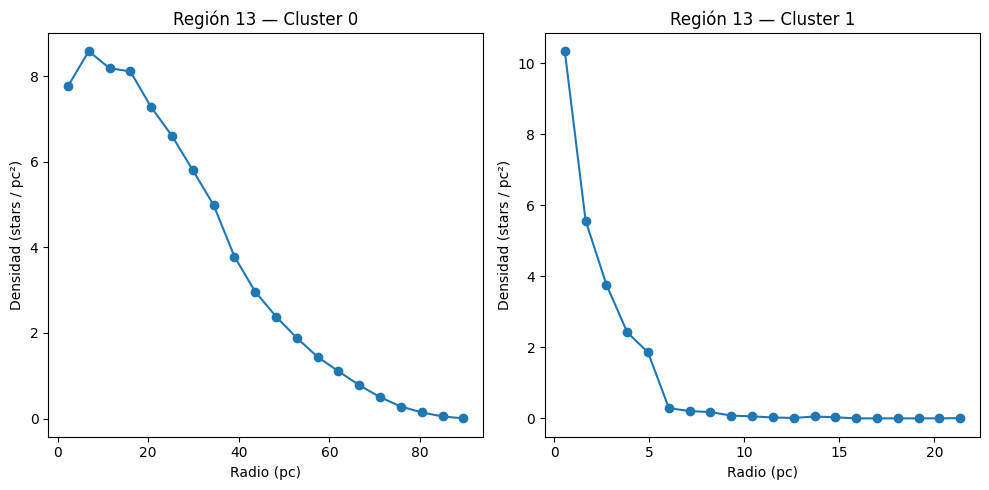


Región 15 — perfiles radiales (pc estrella a estrella)


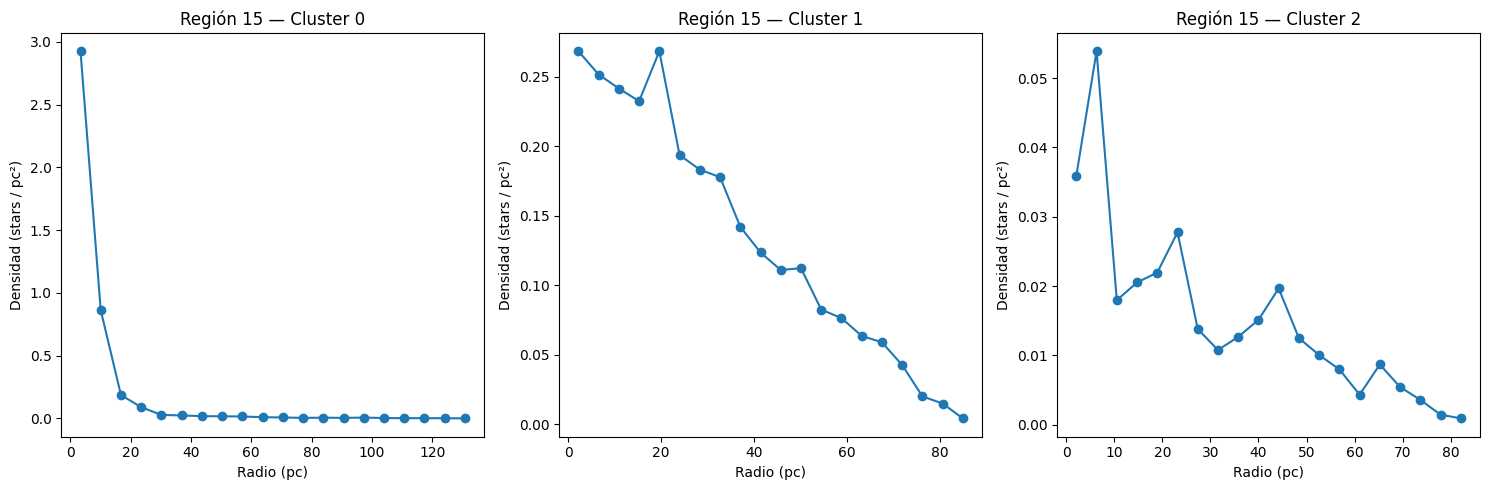


Región 18 — perfiles radiales (pc estrella a estrella)


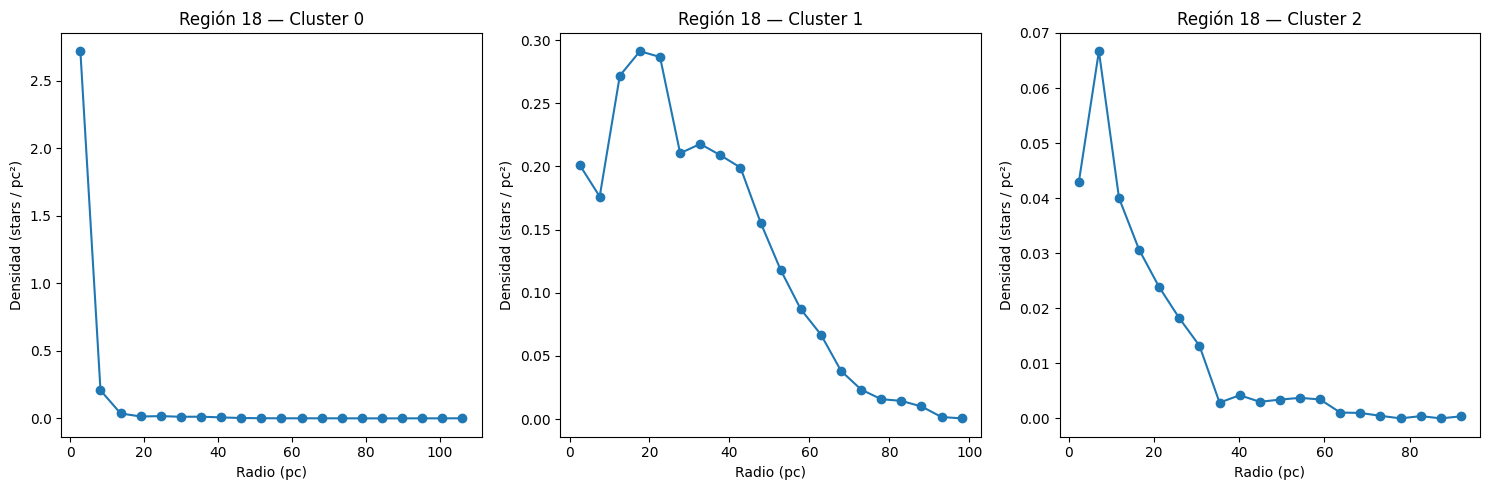


Región 21 — perfiles radiales (pc estrella a estrella)


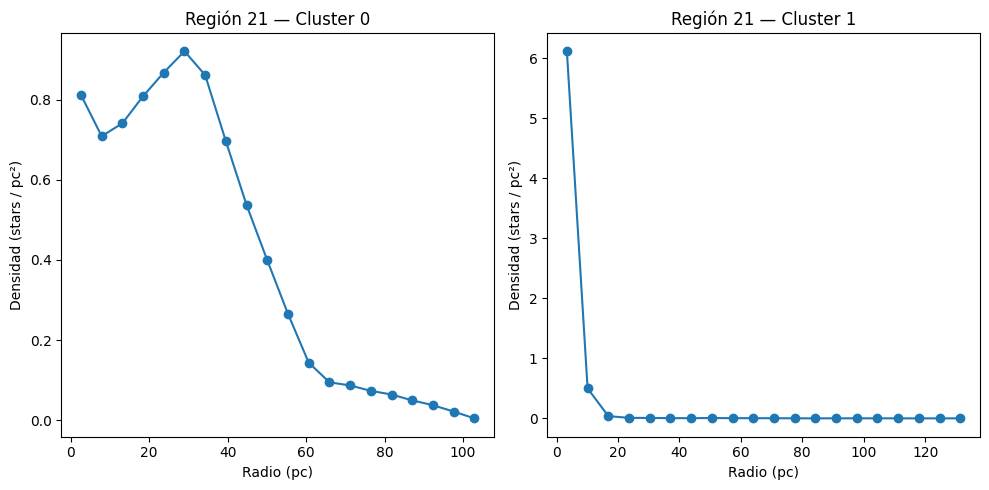


Región 27 — perfiles radiales (pc estrella a estrella)


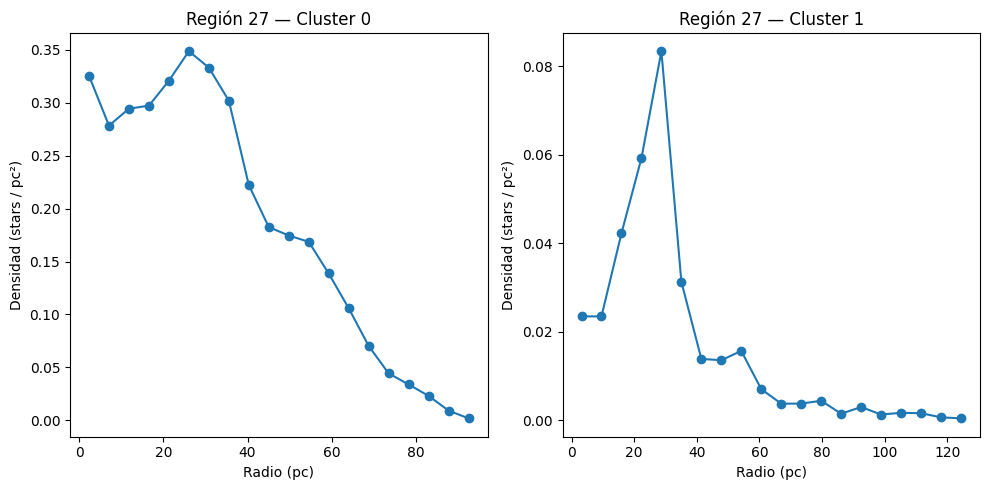


Región 38 — perfiles radiales (pc estrella a estrella)


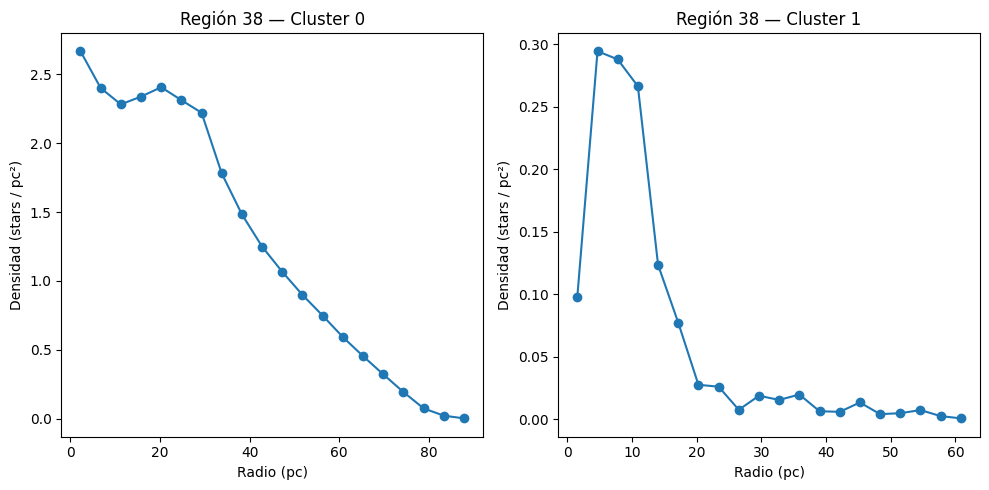


Región 39 — perfiles radiales (pc estrella a estrella)


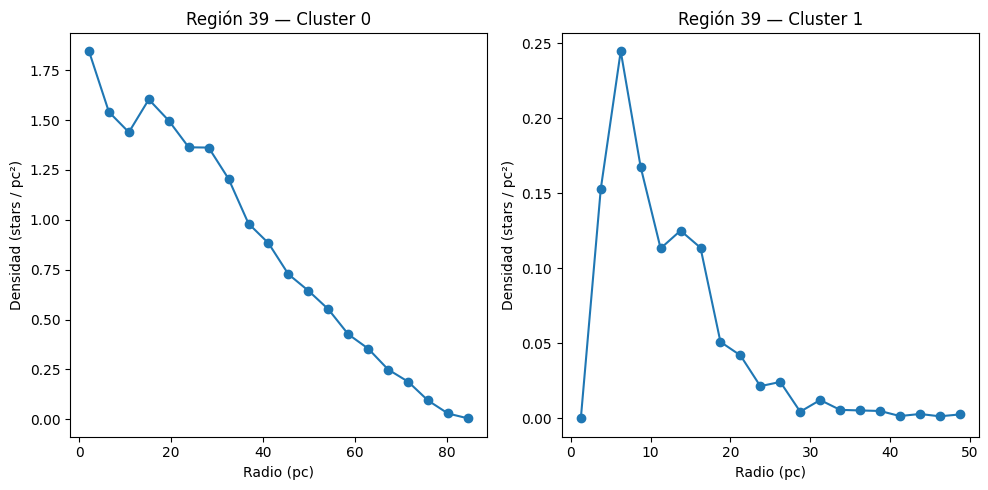

In [13]:
def perfiles_radiales_clusters_pc(ra, dec, pmra, pmdec, parallax,
                                  ra_bins, dec_bins,
                                  df_centros,
                                  regiones_objetivo,
                                  min_cluster_size=100,
                                  min_samples=6,
                                  nbins=20):

    # Reconstruir regiones
    regiones = []
    centinela = 0
    for i in range(8):
        for j in range(8):
            centinela += 1
            regiones.append({
                "id": centinela,
                "ra_min": ra_bins[i],
                "ra_max": ra_bins[i+1],
                "dec_min": dec_bins[j],
                "dec_max": dec_bins[j+1]
            })

    for reg_id in regiones_objetivo:

        region = next((r for r in regiones if r["id"] == reg_id), None)
        if region is None:
            continue

        ra_min, ra_max = region["ra_min"], region["ra_max"]
        dec_min, dec_max = region["dec_min"], region["dec_max"]

        mask = ((ra >= ra_min) & (ra < ra_max) &
                (dec >= dec_min) & (dec < dec_max))

        if np.sum(mask) < 100:
            print(f"Región {reg_id}: muy pocos datos.")
            continue

        # Datos región
        ra_i = ra[mask]
        dec_i = dec[mask]
        pmra_i = pmra[mask]
        pmdec_i = pmdec[mask]
        parallax_i = parallax[mask]

        # Clustering
        data_i = np.column_stack((pmra_i, pmdec_i, parallax_i))
        data_i = RobustScaler().fit_transform(data_i)

        hd = HDBSCAN(min_cluster_size=min_cluster_size,
                     min_samples=min_samples)
        labels = hd.fit_predict(data_i)

        clusters = np.unique(labels[labels != -1])

        print("\n" + "="*60)
        print(f"Región {reg_id} — perfiles radiales (pc estrella a estrella)")

        if len(clusters) == 0:
            print("  No hay clusters.")
            continue

        centros_region = df_centros[df_centros["region"] == reg_id]

        fig, axes = plt.subplots(1, len(clusters), figsize=(5*len(clusters), 5))

        if len(clusters) == 1:
            axes = [axes]

        for idx, c in enumerate(clusters):
            ax = axes[idx]

            mask_c = labels == c

            centro = centros_region[centros_region["cluster"] == c]
            if len(centro) == 0:
                print(f"  Cluster {c}: sin centro.")
                continue

            ra_c = centro["ra_center"].values[0]
            dec_c = centro["dec_center"].values[0]
            
            dra = ra_i[mask_c] - ra_c
            ddec = dec_i[mask_c] - dec_c

            r_deg = np.sqrt(dra**2 + ddec**2)

            par_c = parallax_i[mask_c]

            valid = par_c > 0
            if np.sum(valid) < 20:
                print(f"  Cluster {c}: muy pocas paralajes válidas.")
                continue

            r_deg = r_deg[valid]
            par_c = par_c[valid]

            d_pc_i = 1000.0 / par_c  # distancia estrella a estrella

            r_rad = np.deg2rad(r_deg)
            r_pc = d_pc_i * r_rad

            r_max = np.max(r_pc)
            bins = np.linspace(0, r_max, nbins+1)

            counts, edges = np.histogram(r_pc, bins=bins)

            areas = np.pi * (edges[1:]**2 - edges[:-1]**2)
            density = counts / areas

            r_mid = 0.5 * (edges[1:] + edges[:-1])

            ax.plot(r_mid, density, marker='o')
            ax.set_title(f'Región {reg_id} — Cluster {c}')
            ax.set_xlabel('Radio (pc)')
            ax.set_ylabel('Densidad (stars / pc²)')

        plt.tight_layout()
        plt.show()

perfiles_radiales_clusters_pc(
    ra, dec, pmra, pmdec, parallax,
    ra_bins, dec_bins,
    df_centros,
    regiones
)

Hyades: RA=67.61°, Dec=16.78°, d = 46 pc
Alpha Persei: RA=51.50°, Dec=49.12°, d = 175 pc
IC 2391: RA=130.00°, Dec=-53.00°, d = 150 pc
Coma Berenice: RA=182.98°, Dec=25.28°, d = 86 pc
NGC 2451: RA=116.25°, Dec=-38.20°, d = 190 pc
IC 2602: RA=160.75°, Dec=-64.40°, d = 150 pc
Melotte 186: RA=81.00°, Dec=33.10°, d = 160 pc
Messier 44: RA=130.00°, Dec=19.70°, d = 187 pc
Messier 45: RA=56.75°, Dec=24.12°, d = 136 pc

Región 13

Cluster 0
Centro: RA=69.175, Dec=11.545
Distancia media: 159.9 pc


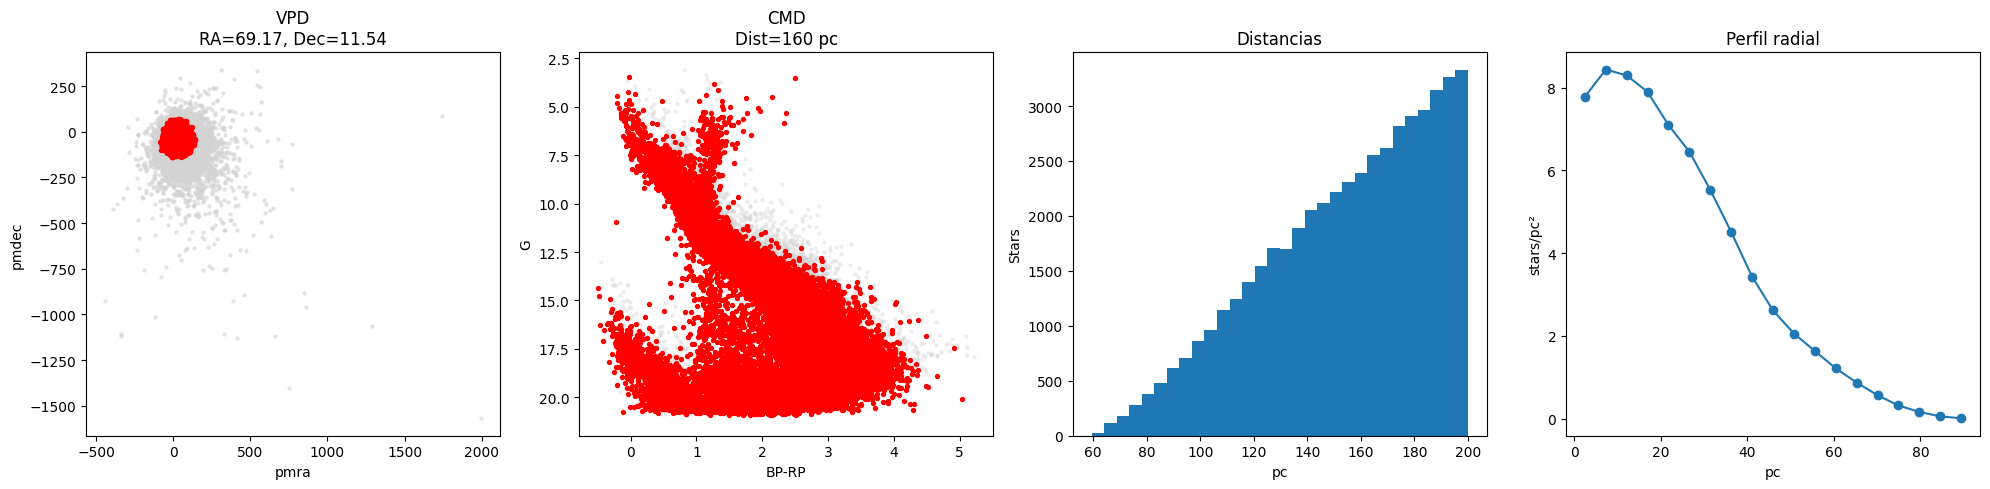


Cluster 1
Centro: RA=67.209, Dec=16.357
Distancia media: 47.6 pc


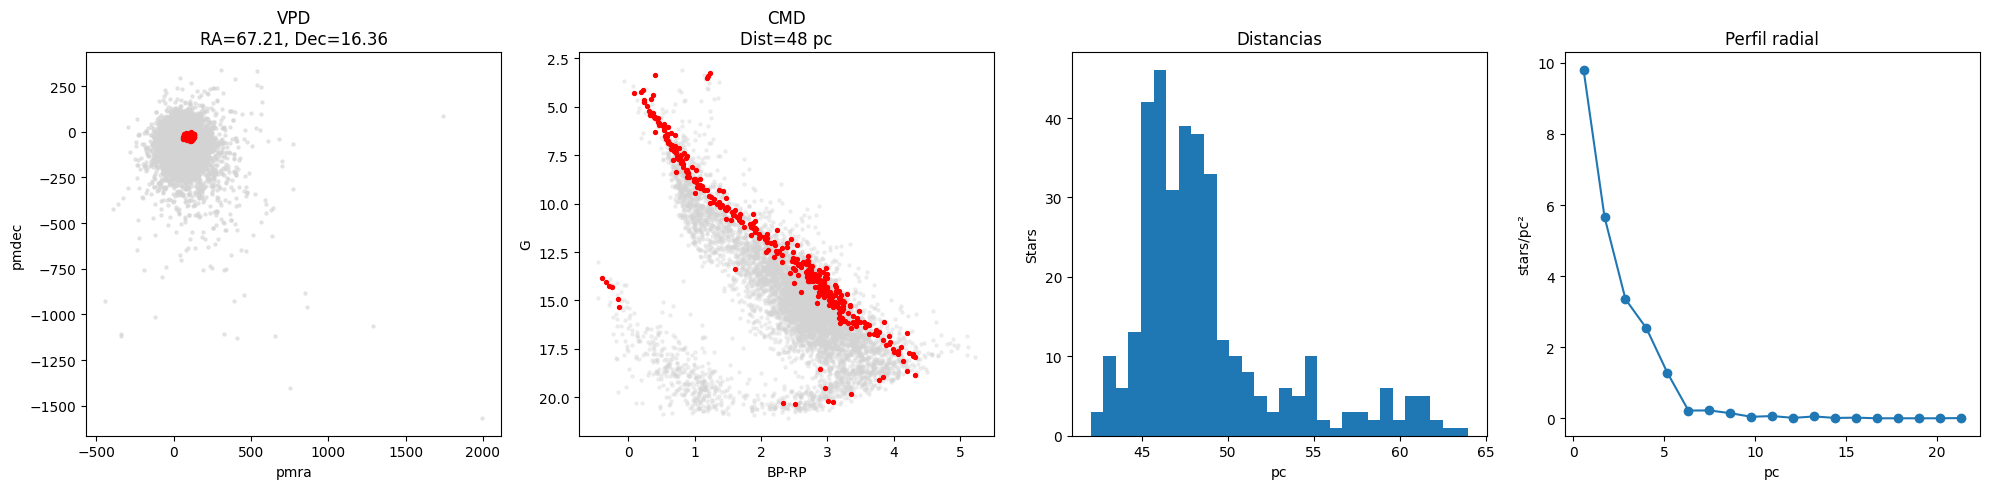


Región 15

Cluster 0
Centro: RA=52.746, Dec=49.384
Distancia media: 177.5 pc


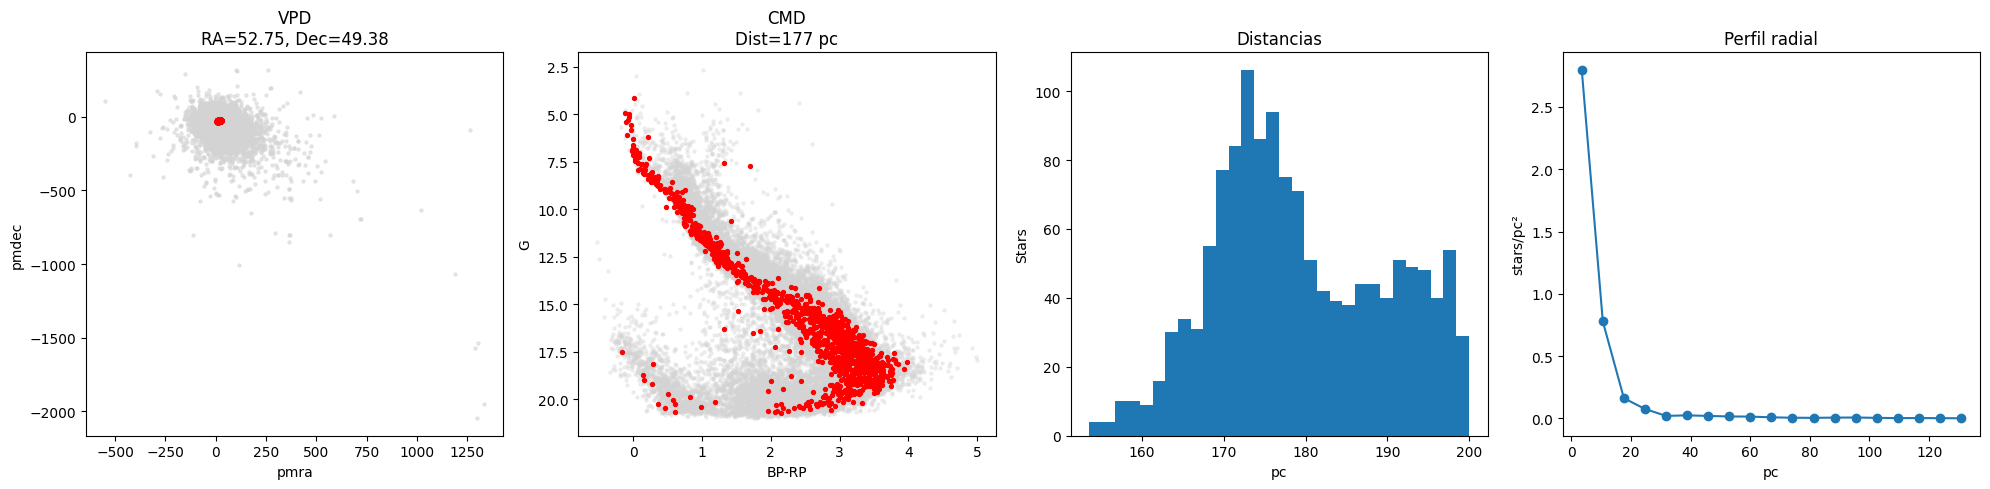


Cluster 1
Centro: RA=66.121, Dec=54.031
Distancia media: 186.7 pc


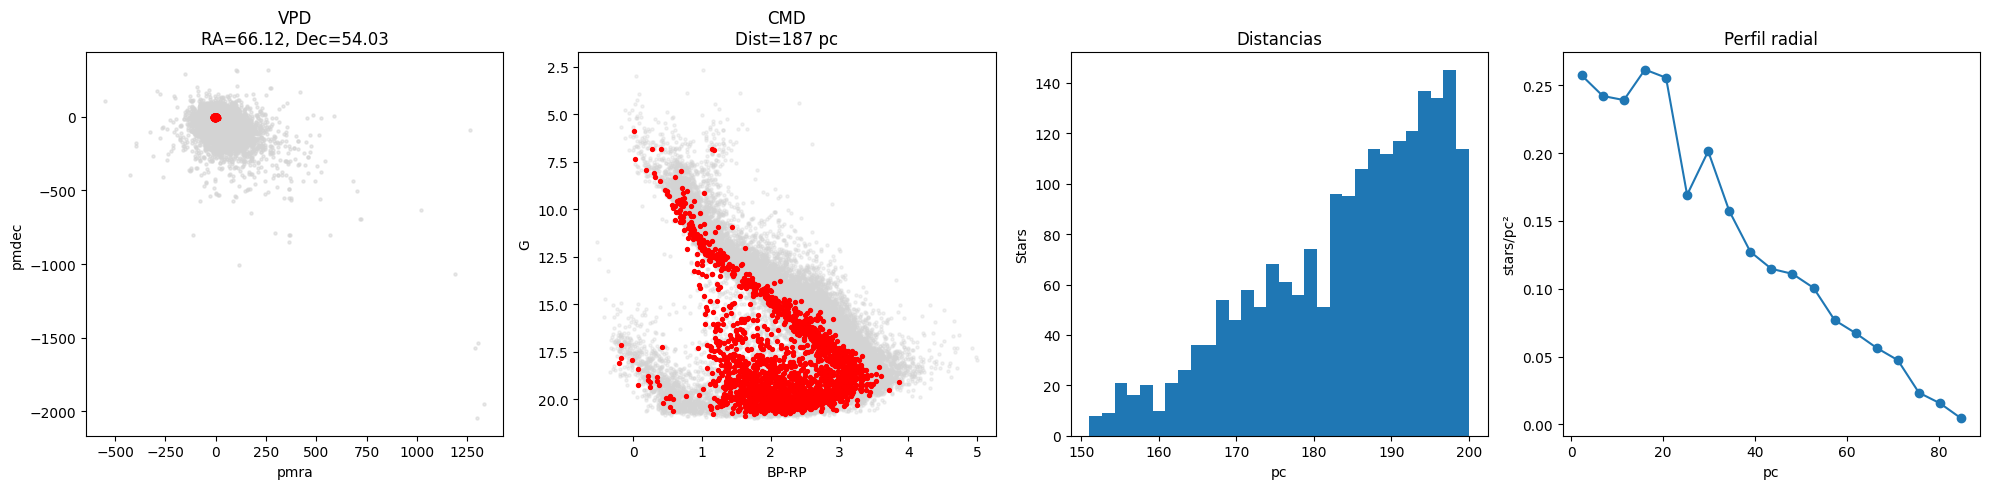


Región 18

Cluster 0
Centro: RA=130.121, Dec=-52.938
Distancia media: 151.8 pc


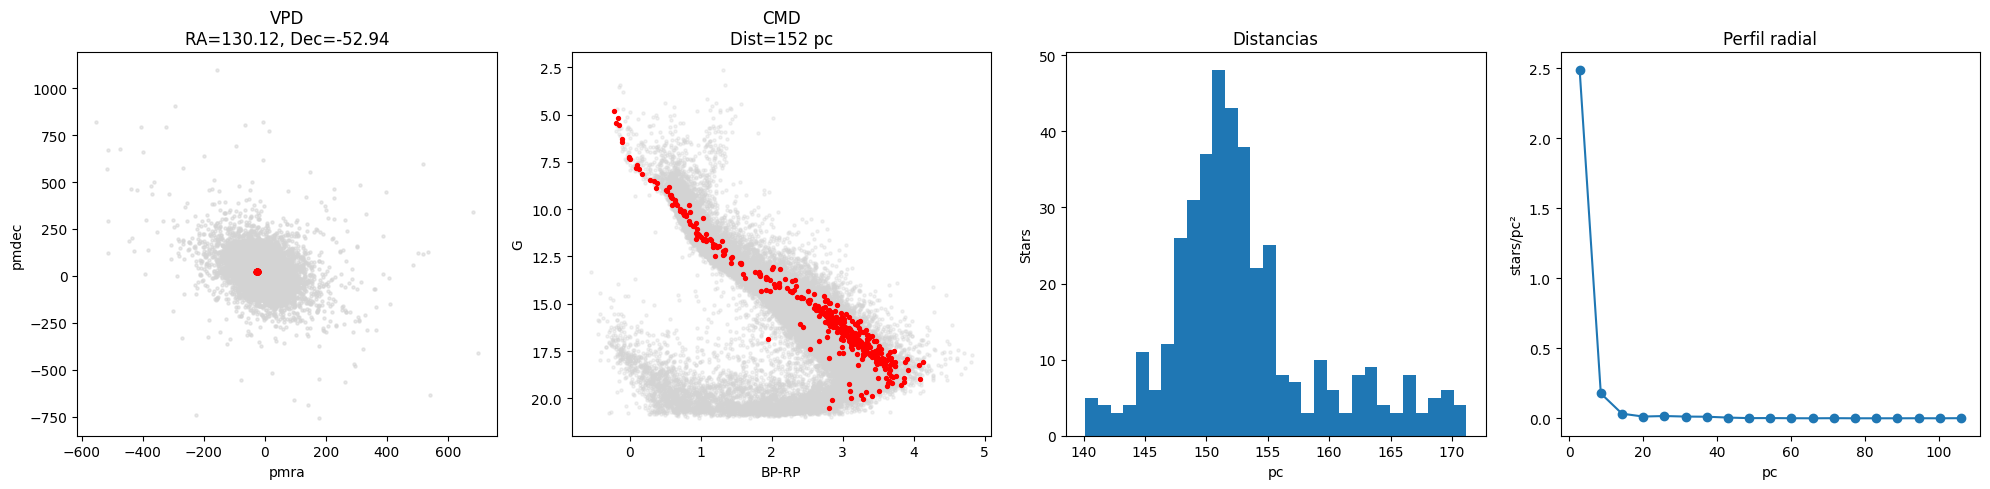


Cluster 1
Centro: RA=116.360, Dec=-52.192
Distancia media: 186.5 pc


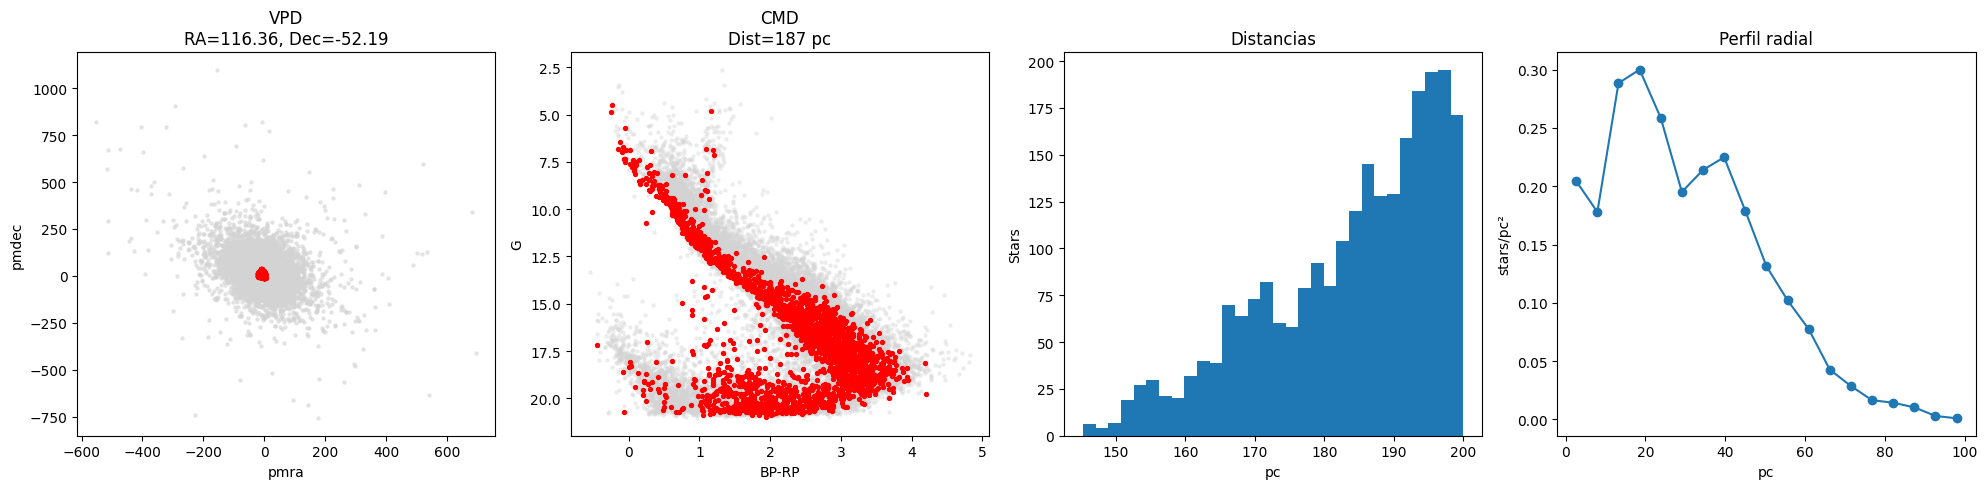


Región 21

Cluster 0
Centro: RA=106.287, Dec=11.023
Distancia media: 185.4 pc


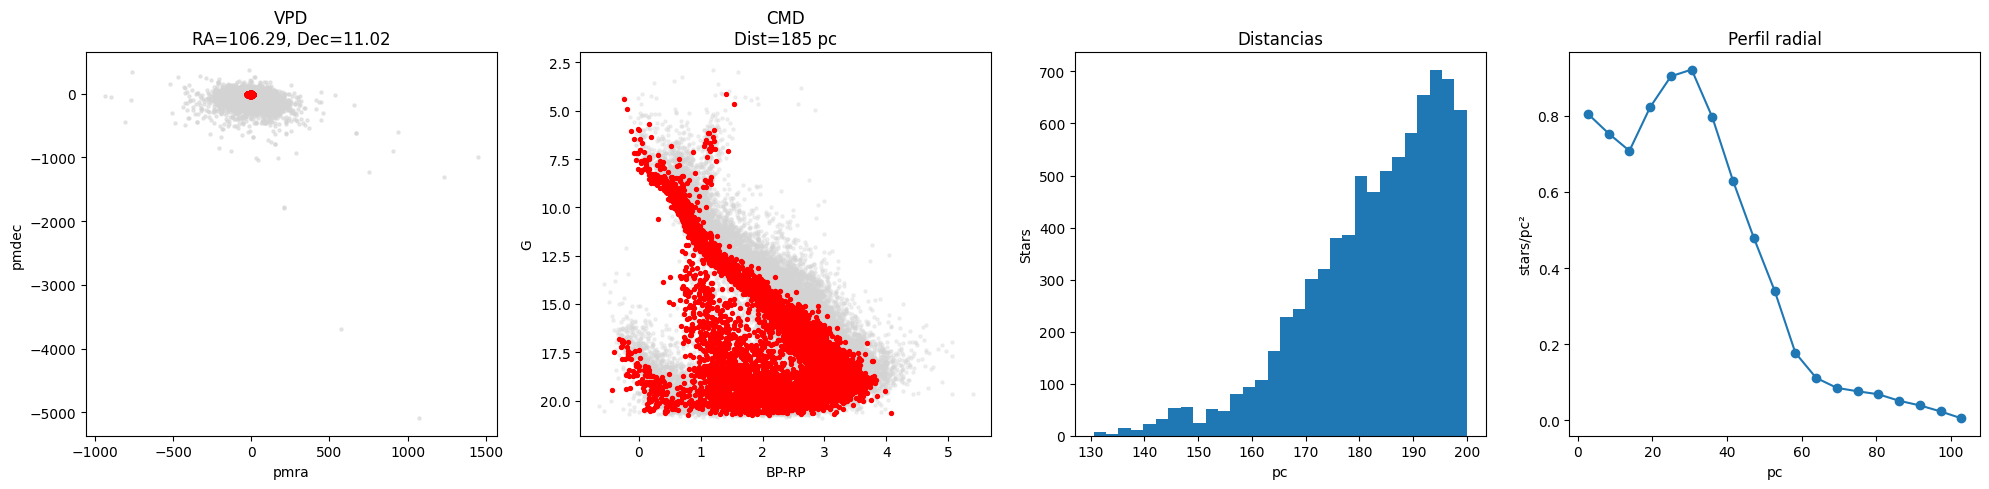


Cluster 1
Centro: RA=129.947, Dec=19.536
Distancia media: 184.9 pc


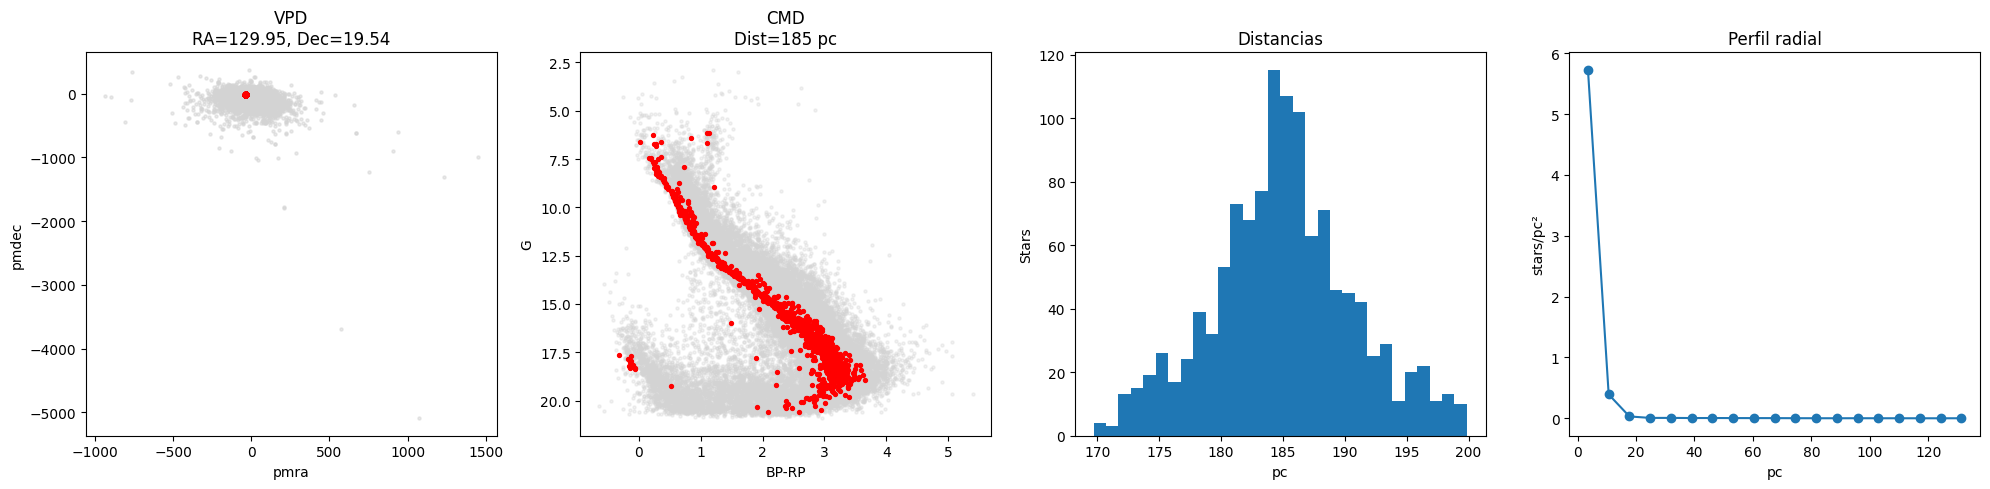


Región 27

Cluster 0
Centro: RA=154.654, Dec=-34.292
Distancia media: 187.2 pc


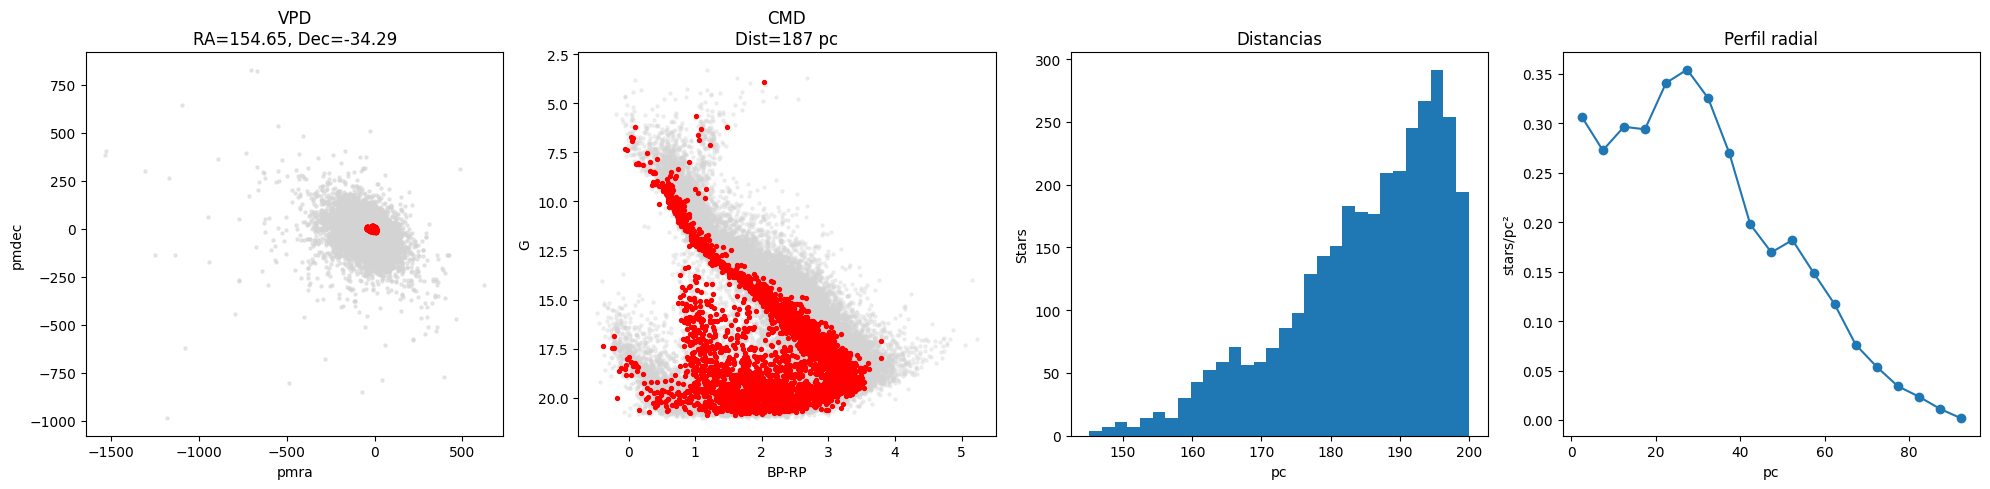


Cluster 1
Centro: RA=145.354, Dec=-38.195
Distancia media: 188.5 pc


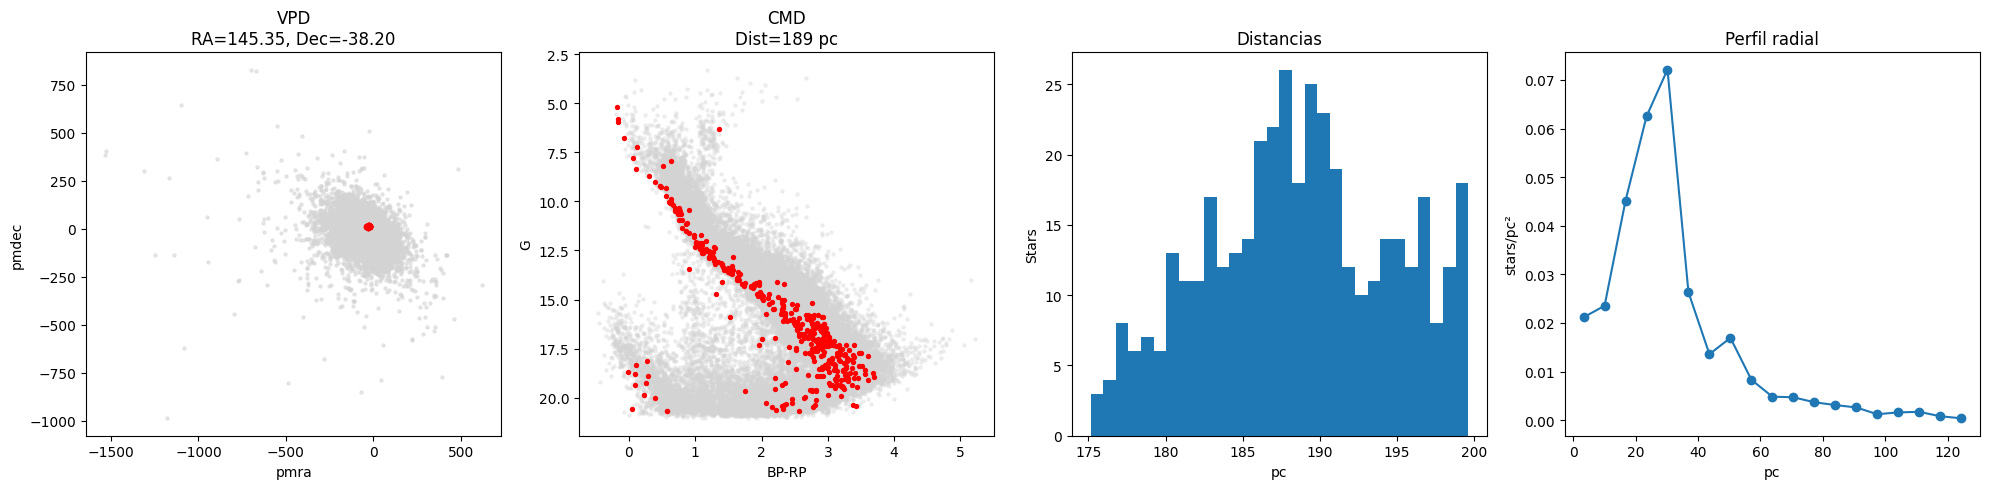


Región 38

Cluster 0
Centro: RA=203.376, Dec=33.220
Distancia media: 171.3 pc


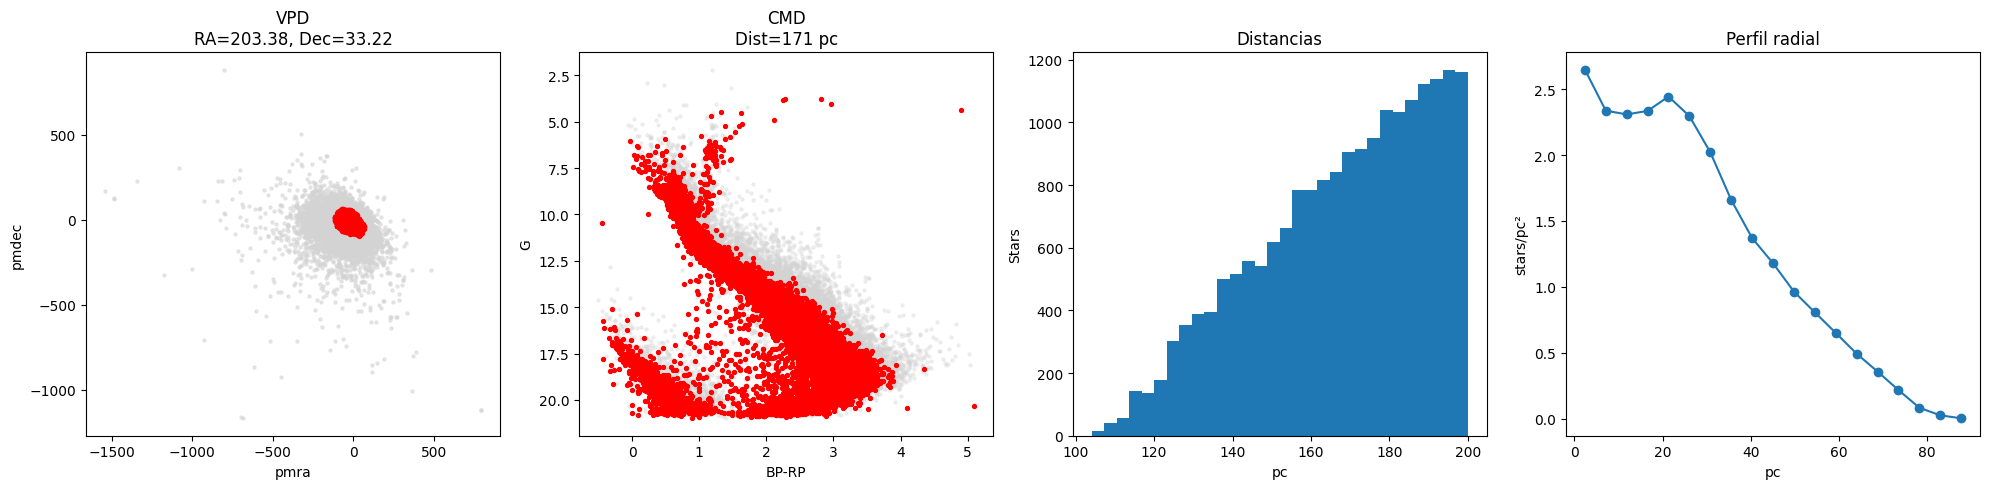


Cluster 1
Centro: RA=192.483, Dec=27.644
Distancia media: 86.9 pc


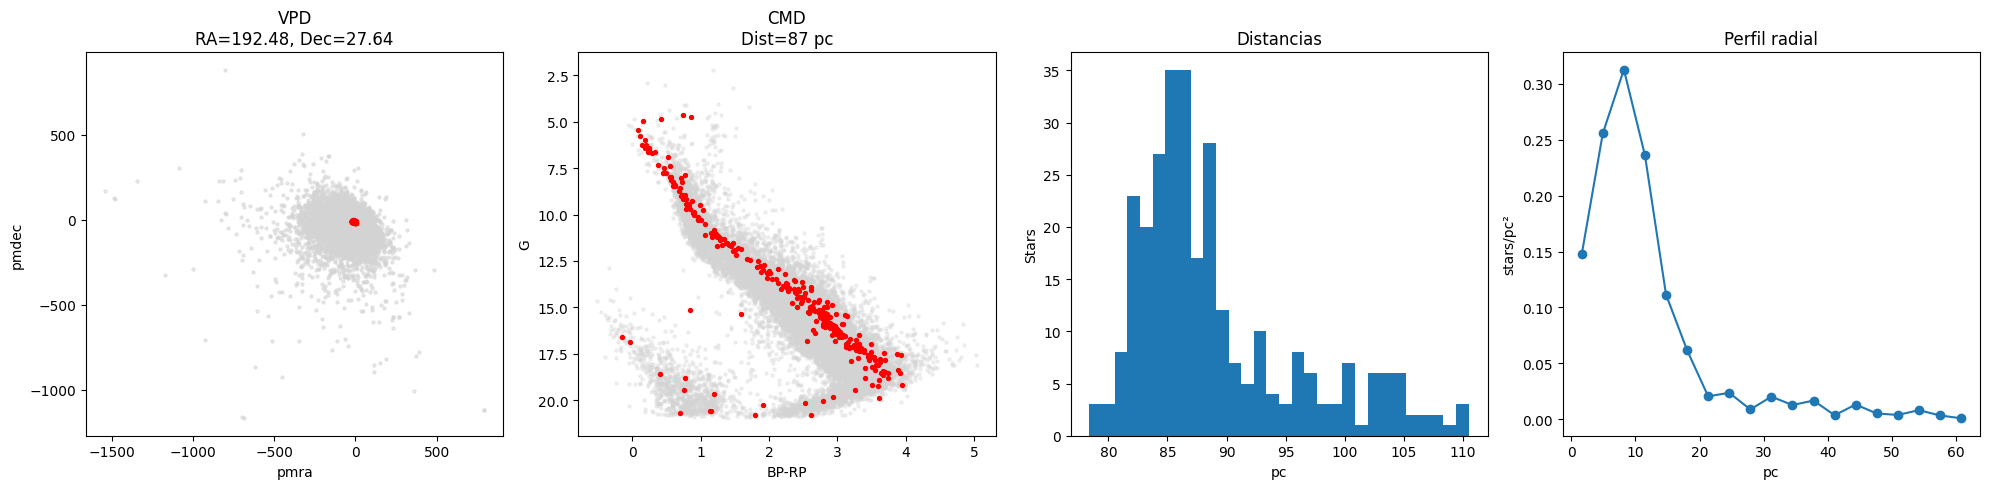


Región 39

Cluster 0
Centro: RA=202.723, Dec=54.847
Distancia media: 174.1 pc


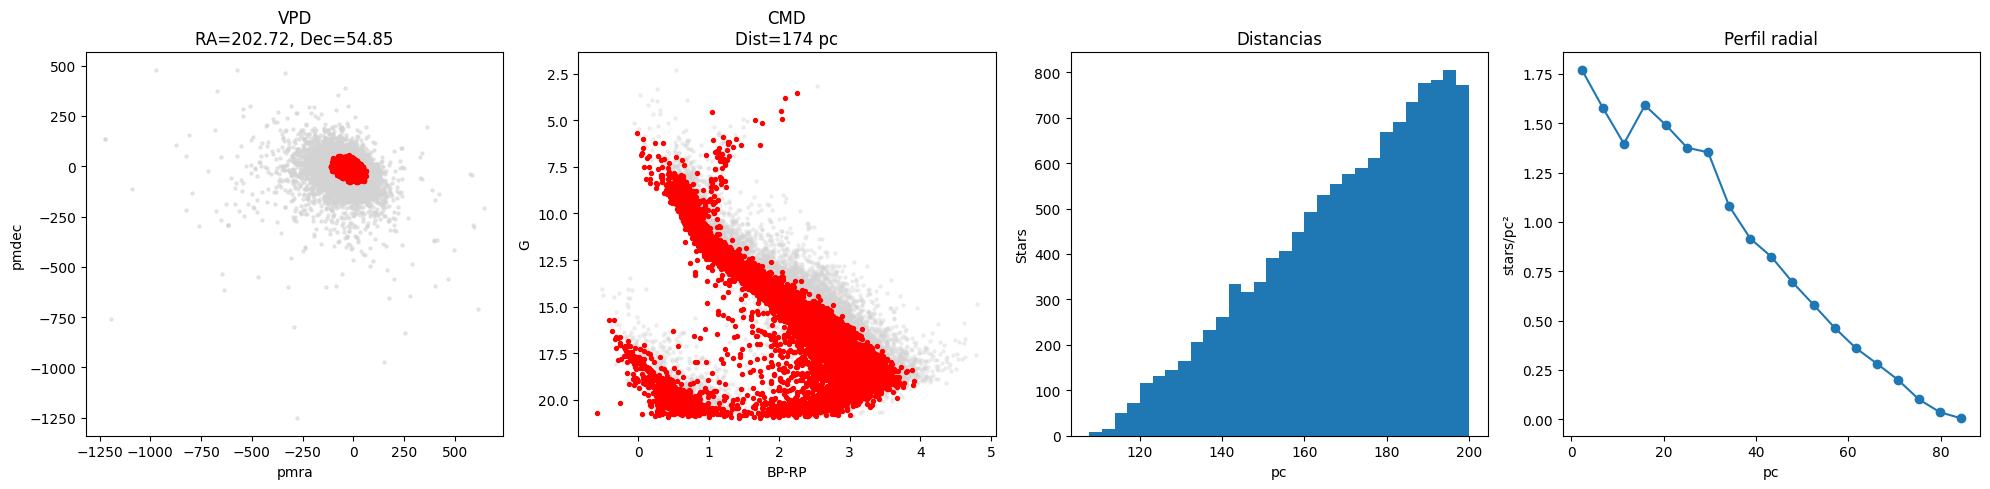


Cluster 1
Centro: RA=210.867, Dec=54.707
Distancia media: 96.4 pc


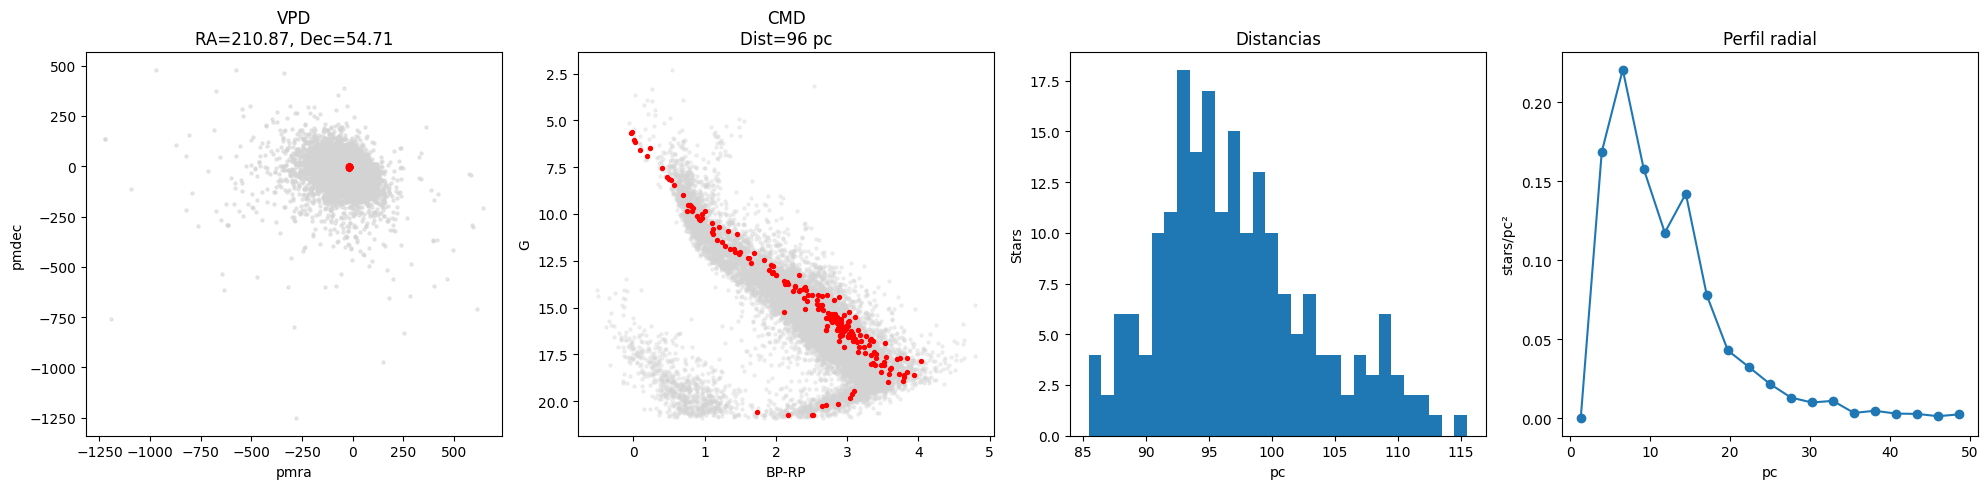

In [15]:
print('Hyades: RA=67.61°, Dec=16.78°, d = 46 pc')
print('Alpha Persei: RA=51.50°, Dec=49.12°, d = 175 pc')
print('IC 2391: RA=130.00°, Dec=-53.00°, d = 150 pc')
print('Coma Berenice: RA=182.98°, Dec=25.28°, d = 86 pc')
print('NGC 2451: RA=116.25°, Dec=-38.20°, d = 190 pc')

print('IC 2602: RA=160.75°, Dec=-64.40°, d = 150 pc')
print('Melotte 186: RA=81.00°, Dec=33.10°, d = 160 pc')
print('Messier 44: RA=130.00°, Dec=19.70°, d = 187 pc')
print('Messier 45: RA=56.75°, Dec=24.12°, d = 136 pc')

regiones = [13, 15, 18, 21, 27, 38,  39]

todas_las_regiones = []
centinela = 0
for i in range(8):
    for j in range(8):
        centinela += 1
        todas_las_regiones.append({
            "id": centinela,
            "ra_min": ra_bins[i],
            "ra_max": ra_bins[i+1],
            "dec_min": dec_bins[j],
            "dec_max": dec_bins[j+1]
        })

for reg_id in regiones:

    region = next((r for r in todas_las_regiones if r["id"] == reg_id), None)
    if region is None:
        continue

    ra_min, ra_max = region["ra_min"], region["ra_max"]
    dec_min, dec_max = region["dec_min"], region["dec_max"]

    mask = ((ra >= ra_min) & (ra < ra_max) &
            (dec >= dec_min) & (dec < dec_max))

    if np.sum(mask) < 100:
        continue

    ra_i = ra[mask]
    dec_i = dec[mask]
    pmra_i = pmra[mask]
    pmdec_i = pmdec[mask]
    parallax_i = parallax[mask]
    g_mag_i = g_mag[mask]
    bp_rp_i = bp_rp[mask]

    # Clustering
    data_i = np.column_stack((pmra_i, pmdec_i, parallax_i))
    data_i = RobustScaler().fit_transform(data_i)

    hd = HDBSCAN(min_cluster_size=100, min_samples=6)
    labels = hd.fit_predict(data_i)

    clusters = np.unique(labels[labels != -1])

    print("\n" + "="*70)
    print(f"Región {reg_id}")

    if len(clusters) == 0:
        print("Solo ruido.")
        continue 

    centros_region = df_centros[df_centros["region"] == reg_id]

    for c in clusters[:2]: 

        mask_c = labels == c

        centro = centros_region[centros_region["cluster"] == c]
        if len(centro) == 0:
            continue

        ra_c = centro["ra_center"].values[0]
        dec_c = centro["dec_center"].values[0]

        par_c = parallax_i[mask_c]
        par_c = par_c[par_c > 0]

        if len(par_c) < 20:
            continue

        d_mean = 1000.0 / np.median(par_c)

        print(f"\nCluster {c}")
        print(f"Centro: RA={ra_c:.3f}, Dec={dec_c:.3f}")
        print(f"Distancia media: {d_mean:.1f} pc")

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        ax = axes[0]

        noise = labels == -1
        ax.scatter(pmra_i[noise], pmdec_i[noise],
                   s=5, c='lightgray', alpha=0.5)

        ax.scatter(pmra_i[mask_c], pmdec_i[mask_c],
                   s=8, c='red')

        ax.set_title(f'VPD\nRA={ra_c:.2f}, Dec={dec_c:.2f}')
        ax.set_xlabel('pmra')
        ax.set_ylabel('pmdec')

        ax = axes[1]

        ax.scatter(bp_rp_i[labels == -1], g_mag_i[labels == -1],
                   s=5, color='lightgray', alpha=0.3)

        ax.scatter(bp_rp_i[mask_c], g_mag_i[mask_c],
                   s=8, color='red')

        ax.set_title(f'CMD\nDist={d_mean:.0f} pc')
        ax.set_xlabel('BP-RP')
        ax.set_ylabel('G')

        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymax, ymin)

        ax = axes[2]

        distances = 1000.0 / par_c
        ax.hist(distances, bins=30)

        ax.set_title('Distancias')
        ax.set_xlabel('pc')
        ax.set_ylabel('Stars')

        ax = axes[3]

        dra = ra_i[mask_c] - ra_c
        ddec = dec_i[mask_c] - dec_c

        r_deg = np.sqrt(dra**2 + ddec**2)

        valid = parallax_i[mask_c] > 0
        r_deg = r_deg[valid]
        par_valid = parallax_i[mask_c][valid]

        d_pc_i = 1000.0 / par_valid

        r_pc = d_pc_i * np.deg2rad(r_deg)

        bins = np.linspace(0, np.max(r_pc), 20)
        counts, edges = np.histogram(r_pc, bins=bins)

        areas = np.pi * (edges[1:]**2 - edges[:-1]**2)
        density = counts / areas

        r_mid = 0.5 * (edges[1:] + edges[:-1])

        ax.plot(r_mid, density, marker='o')

        ax.set_title('Perfil radial')
        ax.set_xlabel('pc')
        ax.set_ylabel('stars/pc²')

        plt.tight_layout()
        plt.show()